# Multiple Linear Regression (Prediksi Produksi Pangan / Panen)

## Penjelasan

### Tujuan

Sebagai data scientist yang dapat membantu petani dan menerapkan SDG (1, 2, 3, 8, 13, 14, 15). Dengan cara memprediksi hasil produksi pangan atau panen menggunakan beberapa aspek seperti Luas Tanah, Temperature, dll. Menggunakan model yang berdasar pada algoritma Linear Regresi.

### Penjelasan Kolom

- ***Kecamatan***: Nama kecamatan daerah tersebut
- ***Tahun***: Tahun produksi
- ***Luas panen***: Luas tanah yang di-panen
- ***Rata-rata produksi***: Rata-rata produksi pangan / panen
- ***Produksi***: Total produksi pangan / panen
- ***Tavg***: Temperatur rata-rata(°C) 
- ***RH_avg***: Kelembapan rata-rata(%) 
- ***RR***: Curah hujan(mm) 
- ***ss***: Lamanya penyinaran matahari(jam)


In [646]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

try:
    df = pd.read_csv("PrediksiPanenPadi_missing_4percent_feature_2percent_target.csv")
    print("Berhasil Membaca Data")
except Exception as e:
    print(f"Gagal Membaca Data as {e}")

Berhasil Membaca Data


## A. Data Understanding

### A.1 Melihat 5 data Teratas dan Terbawah

In [647]:
df.head()

,Kecamatan,Tahun,LUAS PANEN,RATA-RATA PRODUKSI,PRODUKSI,TAVG,RH_AVG,RR,SS
0,Ampelgading,2009,600.9375,59.280000,3562.357500,23.598470,75.516526,4.234178,5.550086
1,Ampelgading,2010,578.8230,61.379000,3552.757692,23.888796,81.300262,7.764491,4.738449
2,Ampelgading,2011,NaN,61.379000,3800.624507,23.431632,77.302067,31.922385,4.628453
3,Ampelgading,2012,1952.8460,63.477429,12396.164410,23.276843,76.709991,48.637837,4.148857
4,Ampelgading,2013,2195.1045,79.299186,17407.000000,23.958065,85.193548,11.800000,2.906452


In [648]:
df.tail()

,Kecamatan,Tahun,LUAS PANEN,RATA-RATA PRODUKSI,PRODUKSI,TAVG,RH_AVG,RR,SS
523,Wonosari,2020,1152.8385,71.193333,8207.441561,24.383265,78.491617,29.813670,6.258836
524,Wonosari,2021,1397.0595,71.193333,9946.132267,24.127649,79.604268,27.216512,5.638221
525,Wonosari,2022,1383.5985,71.193333,9850.298921,24.035501,80.462052,44.884746,5.377241
526,Wonosari,2023,1158.6075,NaN,7552.962293,24.368025,76.102490,6.534430,5.962496
527,Wonosari,2024,NaN,66.252753,6816.116389,25.396780,77.126717,59.136172,5.818983


### A.2 Melihat Struktur Dataset

In [649]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 528 entries, 0 to 527
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Kecamatan           528 non-null    str    
 1   Tahun               528 non-null    int64  
 2   LUAS PANEN          507 non-null    float64
 3   RATA-RATA PRODUKSI  507 non-null    float64
 4   PRODUKSI            518 non-null    float64
 5   TAVG                507 non-null    float64
 6   RH_AVG              507 non-null    float64
 7   RR                  507 non-null    float64
 8   SS                  507 non-null    float64
dtypes: float64(7), int64(1), str(1)
memory usage: 37.3 KB


### A.3 Melihat Nilai Unik Di Columns

In [650]:
for col in df:
    print(f"Nilai Unik Kolom: {col}")
    print(df[col].unique())
    print('--' * 30)

Nilai Unik Kolom: Kecamatan
<StringArray>
[  'Ampelgading',        'Bantur',    'Bululawang',        'Dampit',
           'Dau',     'Donomulyo',      'Gedangan',  'Gondanglegi ',
        'Jabung',      'Kalipare',   'Karangploso',      'Kasembon',
      'Kepanjen',     'Kromengan',        'Lawang',        'Ngajum',
      'Ngantang',         'Pagak',     'Pagelaran',         'Pakis',
      'Pakisaji',   'Poncokusumo',         'Pujon',     'Singosari',
 'Sumbermanjing',  'Sumberpucung',       'Tajinan',     'Tirtoyudo',
       'Tumpang',         'Turen',         'Wagir',         'Wajak',
      'Wonosari']
Length: 33, dtype: str
------------------------------------------------------------
Nilai Unik Kolom: Tahun
[2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022
 2023 2024]
------------------------------------------------------------
Nilai Unik Kolom: LUAS PANEN
[6.0093750e+02 5.7882300e+02           nan 1.9528460e+03 2.1951045e+03
 1.6605105e+03 1.9460000e+03 2.21625

### A.4 Melihat Missing Columns

In [651]:
miss = pd.DataFrame({
    'Tipe' : df.dtypes,
    'Null' : df.isnull().sum(),
    'Persen (%)' : (df.isnull().sum() / len(df)) * 100,
    'contoh' : df.isnull().sum()
})

miss_sum = miss[miss['Null'] > 0].sort_values(by = 'Null', ascending=False)

miss_sum

,Tipe,Null,Persen (%),contoh
LUAS PANEN,float64,21,3.977273,21
RATA-RATA PRODUKSI,float64,21,3.977273,21
TAVG,float64,21,3.977273,21
RR,float64,21,3.977273,21
RH_AVG,float64,21,3.977273,21
SS,float64,21,3.977273,21
PRODUKSI,float64,10,1.893939,10


### A.5 Melihat Duplikasi Data

In [652]:
total = len(df)
dup = df.duplicated().sum()
persen = (dup / total) * 100

print(f"Presentase Duplikasi Data {persen:.2f}")

Presentase Duplikasi Data 0.00


**insight :**
- Data Mempunyai Missing Values Di Kolom Numerik Terutama (Float)
- Data Bersih Dari Duplikasi
- Kolom Tahun Harusnya Format Datetime

**Tindakan :**
- Handling Missing Val
- Handling Kolom Tahun

## B. Data Cleaning

### B.1 Handling Missing Values

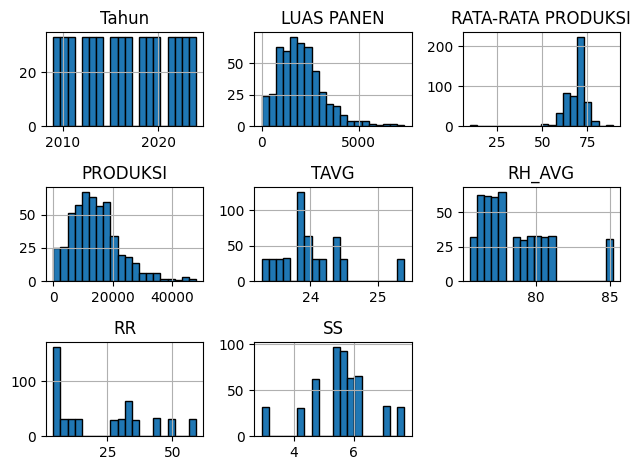

In [653]:
num = df.select_dtypes(include='number')
num.hist(bins = 20, edgecolor = 'black')
plt.tight_layout()
plt.show()

In [654]:
df.columns

Index(['Kecamatan', 'Tahun', 'LUAS PANEN', 'RATA-RATA PRODUKSI', 'PRODUKSI',
       'TAVG', 'RH_AVG', 'RR', 'SS'],
      dtype='str')

In [655]:
df.head()

,Kecamatan,Tahun,LUAS PANEN,RATA-RATA PRODUKSI,PRODUKSI,TAVG,RH_AVG,RR,SS
0,Ampelgading,2009,600.9375,59.280000,3562.357500,23.598470,75.516526,4.234178,5.550086
1,Ampelgading,2010,578.8230,61.379000,3552.757692,23.888796,81.300262,7.764491,4.738449
2,Ampelgading,2011,NaN,61.379000,3800.624507,23.431632,77.302067,31.922385,4.628453
3,Ampelgading,2012,1952.8460,63.477429,12396.164410,23.276843,76.709991,48.637837,4.148857
4,Ampelgading,2013,2195.1045,79.299186,17407.000000,23.958065,85.193548,11.800000,2.906452


In [656]:
df_clean = df.copy()

In [657]:
df_clean.dropna(inplace=True)

In [658]:
# med = df_clean[['LUAS PANEN', 'RATA-RATA PRODUKSI', 'PRODUKSI',
#        'TAVG', 'RH_AVG', 'RR', 'SS']]

# for col in med:
#     median = df_clean[col].median()
#     df_clean[col] = df_clean[col].fillna(median)
#     print(f"Kolom {col} Diisi Dengan: {median}")

### B.2 Ubah Format Tahun

In [659]:
df_clean['Tahun'] = pd.to_datetime(df_clean['Tahun'], errors='coerce')

In [660]:
df_clean['Tahun'].dtypes

dtype('<M8[ns]')

### B.3 Recheck Lagi

In [661]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 403 entries, 0 to 525
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Kecamatan           403 non-null    str           
 1   Tahun               403 non-null    datetime64[ns]
 2   LUAS PANEN          403 non-null    float64       
 3   RATA-RATA PRODUKSI  403 non-null    float64       
 4   PRODUKSI            403 non-null    float64       
 5   TAVG                403 non-null    float64       
 6   RH_AVG              403 non-null    float64       
 7   RR                  403 non-null    float64       
 8   SS                  403 non-null    float64       
dtypes: datetime64[ns](1), float64(7), str(1)
memory usage: 31.5 KB


In [662]:
miss = pd.DataFrame({
    'Tipe' : df_clean.dtypes,
    'Null' : df_clean.isnull().sum(),
    'Persen (%)' : (df_clean.isnull().sum() / len(df)) * 100,
    'contoh' : df_clean.isnull().sum()
})

miss_sum = miss[miss['Null'] > 0].sort_values(by = 'Null', ascending=False)

miss_sum

,Tipe,Null,Persen (%),contoh


**insight :**
- Data Ini Extreme Skew 
- Kolom tahun Sudah Bertipe Datetime
- Missing Values Ditangani Dengan Median

**Tindakan :**
- Handling Missing Val
- Handling Kolom Tahun

## C. Exploratory Data Analysis (EDA)

### C.1 Univariate Analysis

####  Persebaran Kolom Numerik

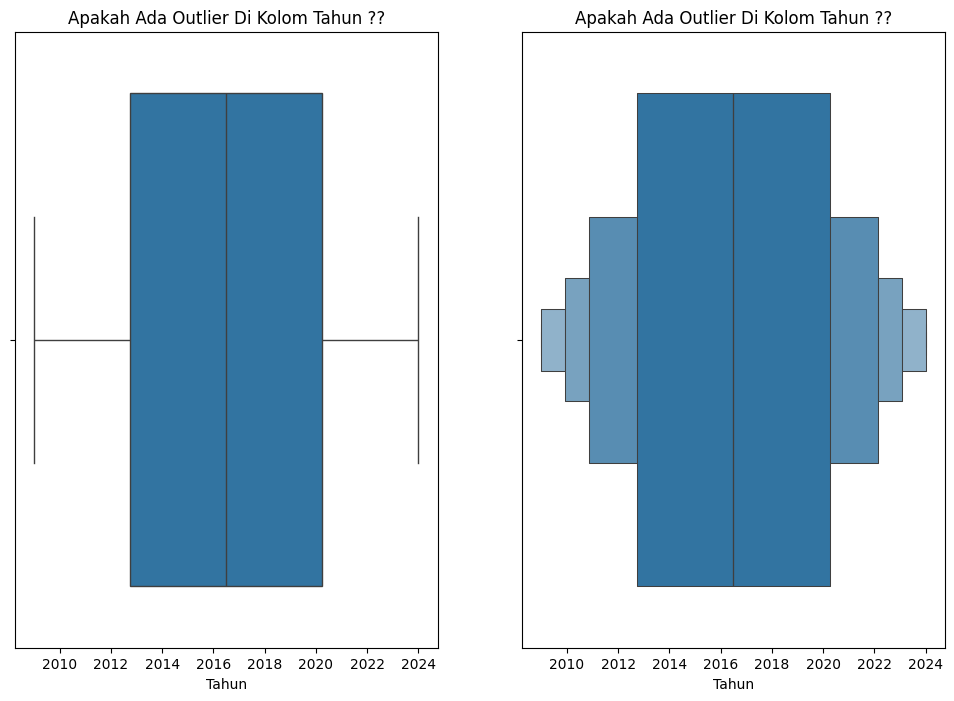

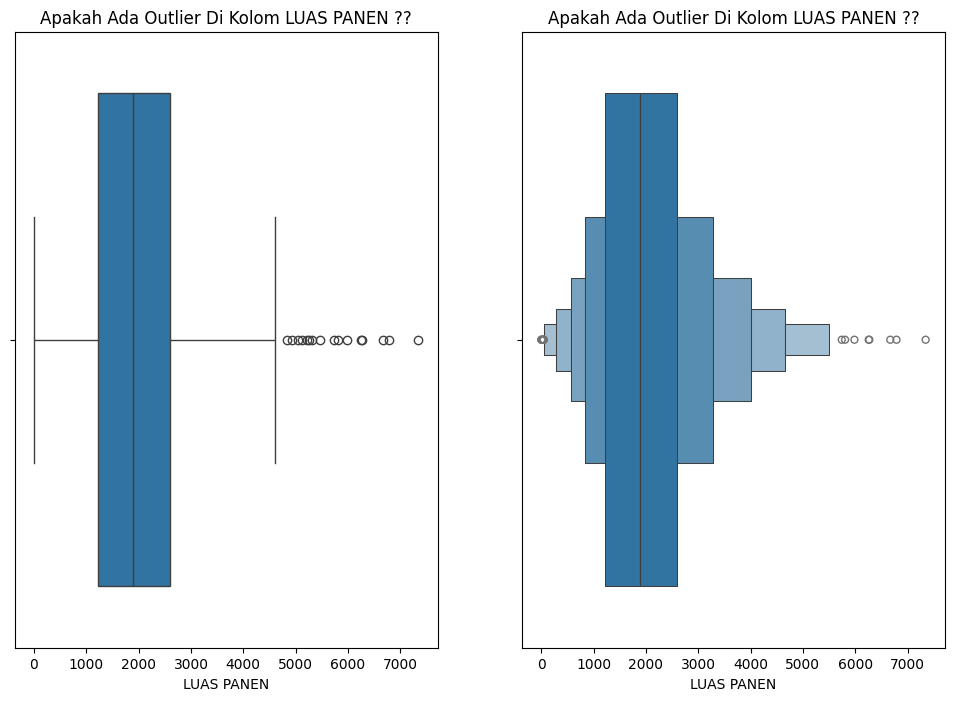

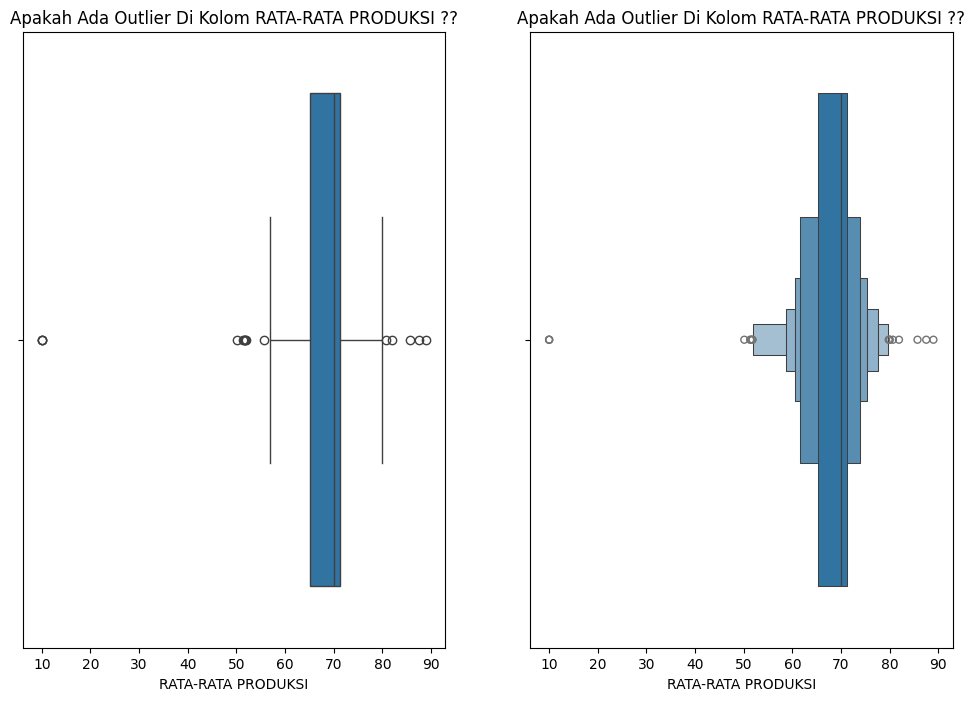

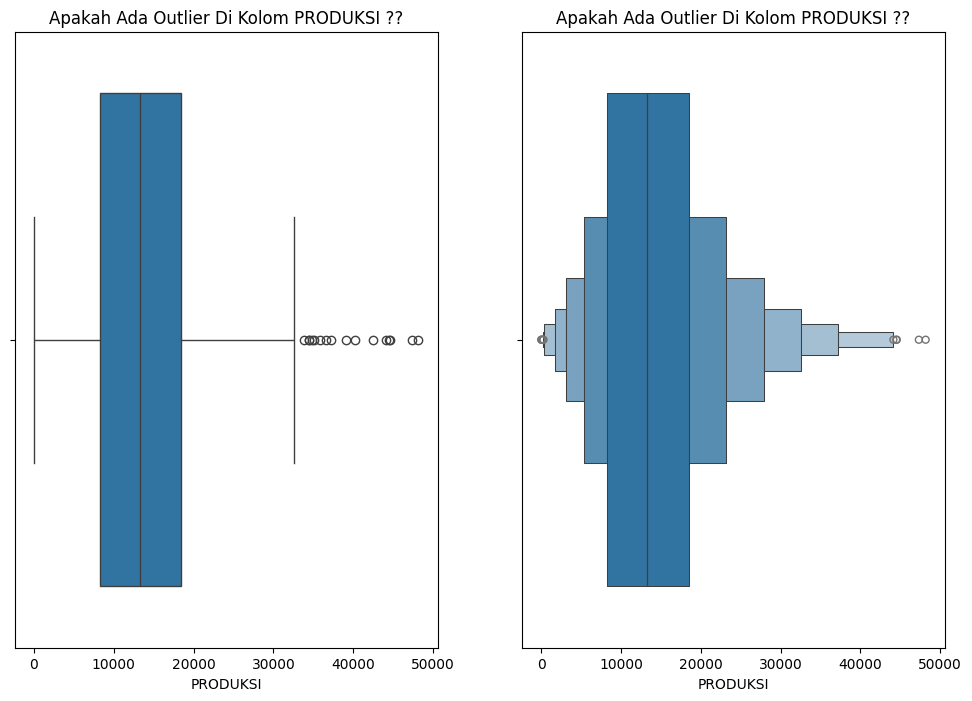

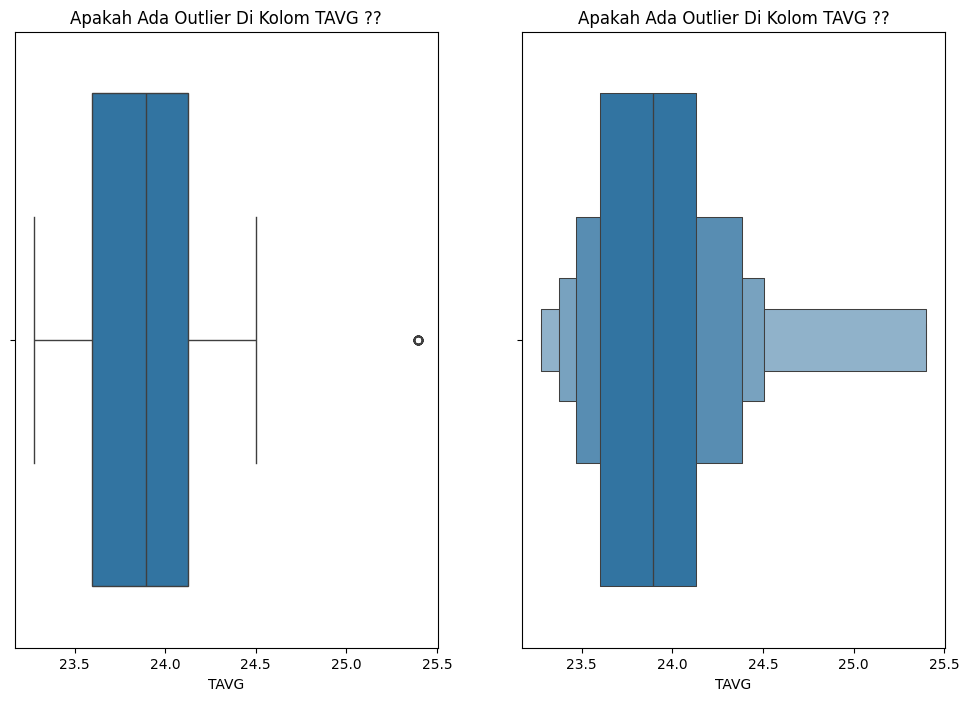

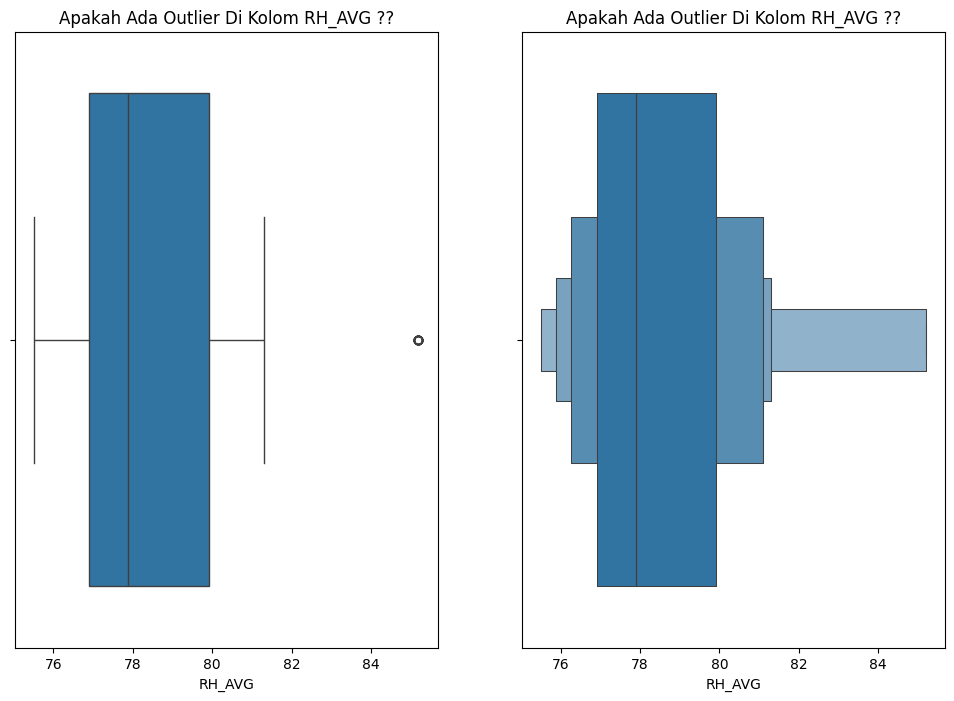

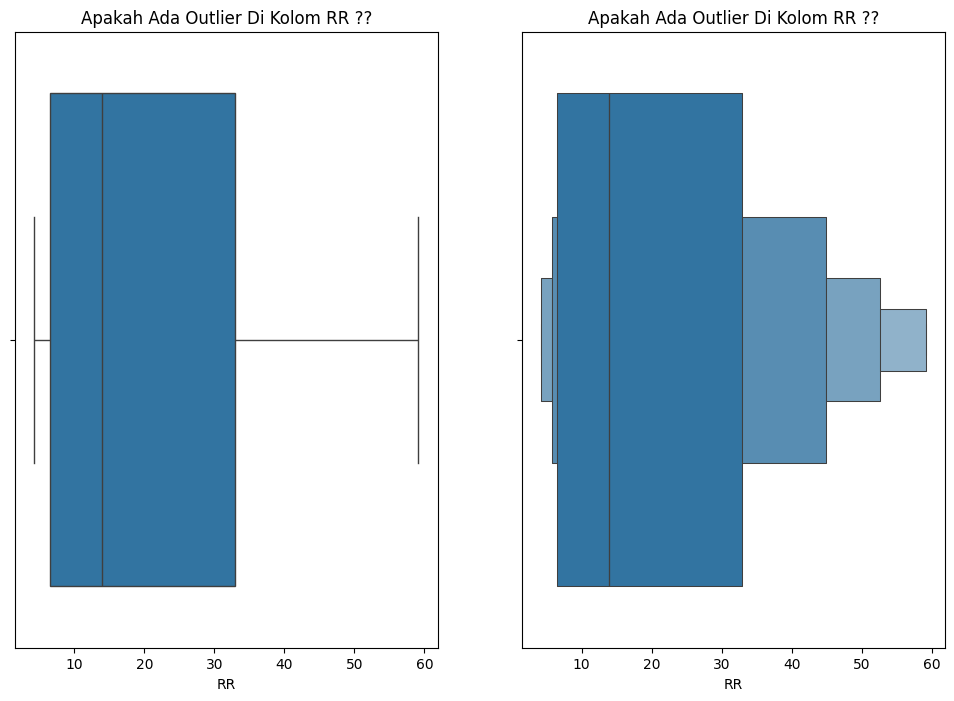

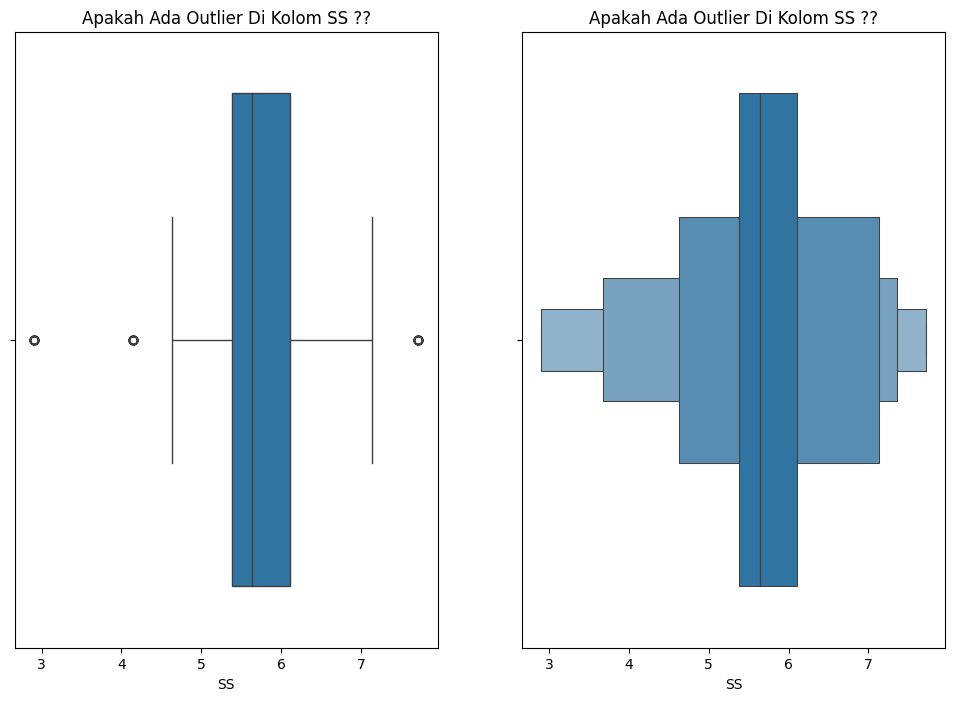

In [663]:
for col in num: 
    fig, ax = plt.subplots(1,2, figsize=(12, 8))
    sns.boxplot(df, x = col, ax = ax[0])
    ax[0].set_title(f"Apakah Ada Outlier Di Kolom {col} ??")

    sns.boxenplot(df, x = col, ax = ax[1])
    ax[1].set_title(f"Apakah Ada Outlier Di Kolom {col} ??")

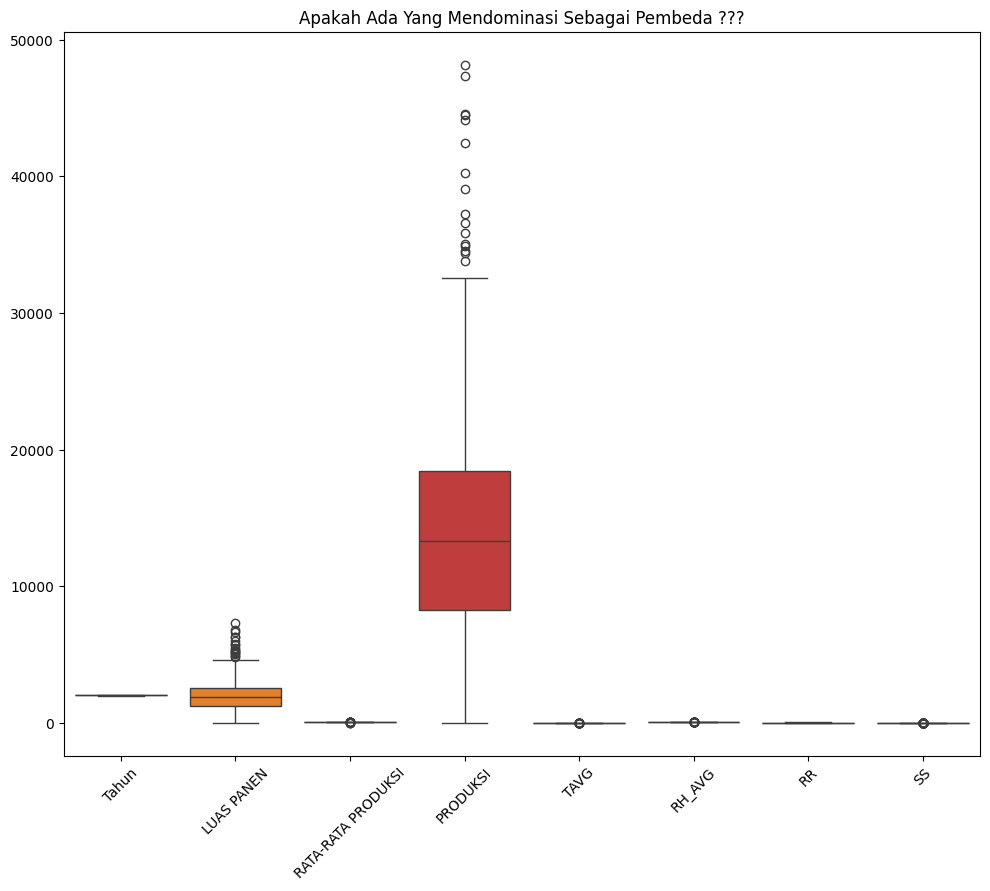

In [664]:
plt.figure(figsize=(10, 8))
sns.boxplot(num)
plt.title("Apakah Ada Yang Mendominasi Sebagai Pembeda ???")
plt.tight_layout()
plt.xticks(rotation = 45)
plt.show()

### Persebarean Kategorik

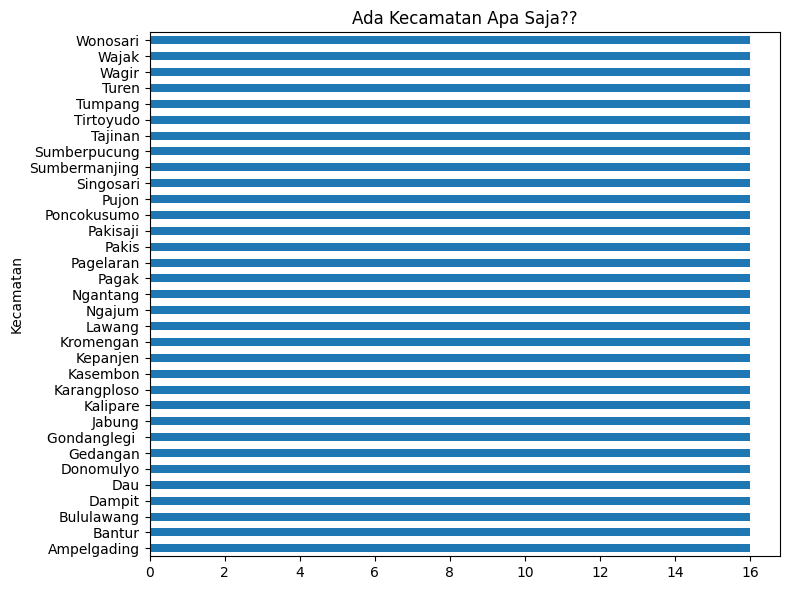

In [665]:
plt.figure(figsize=(8, 6))
df['Kecamatan'].value_counts(ascending=False).plot(kind='barh')
plt.title("Ada Kecamatan Apa Saja??")
plt.tight_layout()
plt.show()

**insight :**
- Terdapat Nilai Anomali
- Rata2 Data Ini Skalanya Berbeda
- Kolom Prediksi dan Luas Panen Menjadi Pola Penting
- Ada Macam2 Kecamatan Dan Semua Punya Jumlah Panen Yang Sama Banyaknya

**Tindakan :**
- Keep Nilai Anomali Karna Masih Batas Wajar
- Disarankan Melakukan Scaling
- Melakukan Analisis Lebih Lanjut Pada Kolom Produksi dan Luas Panen

### C.2 Bivariate Analysis

####  Numerik vs Numerik

#### Melihat Pola Linearitas Setiap Kolom

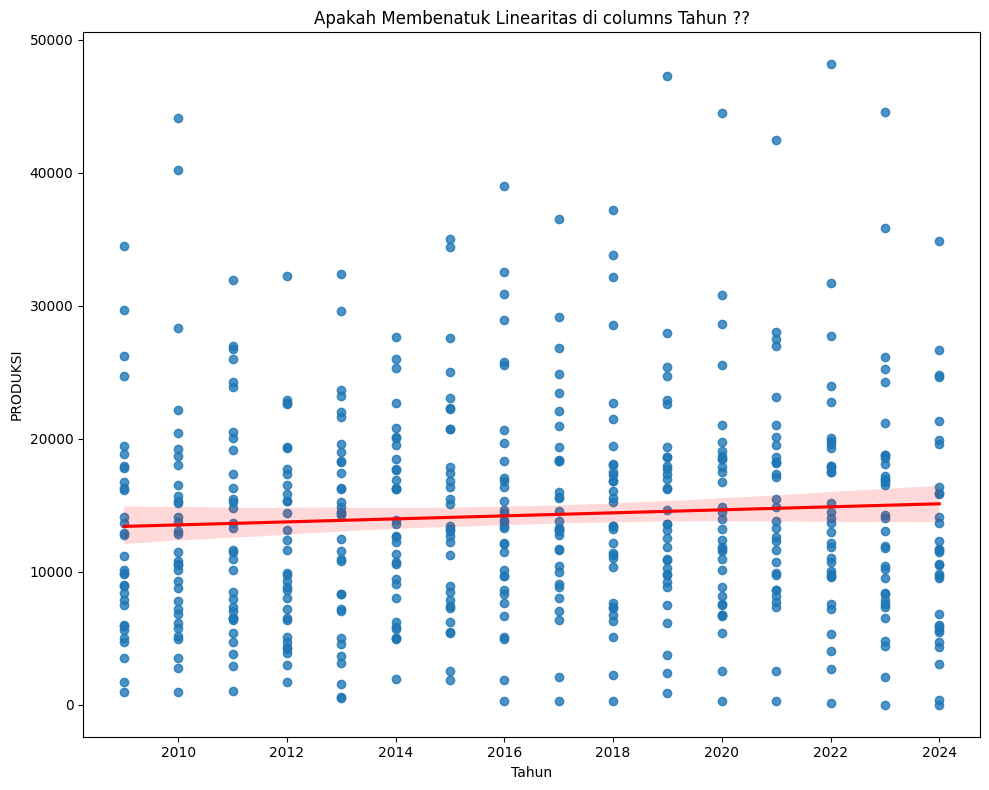

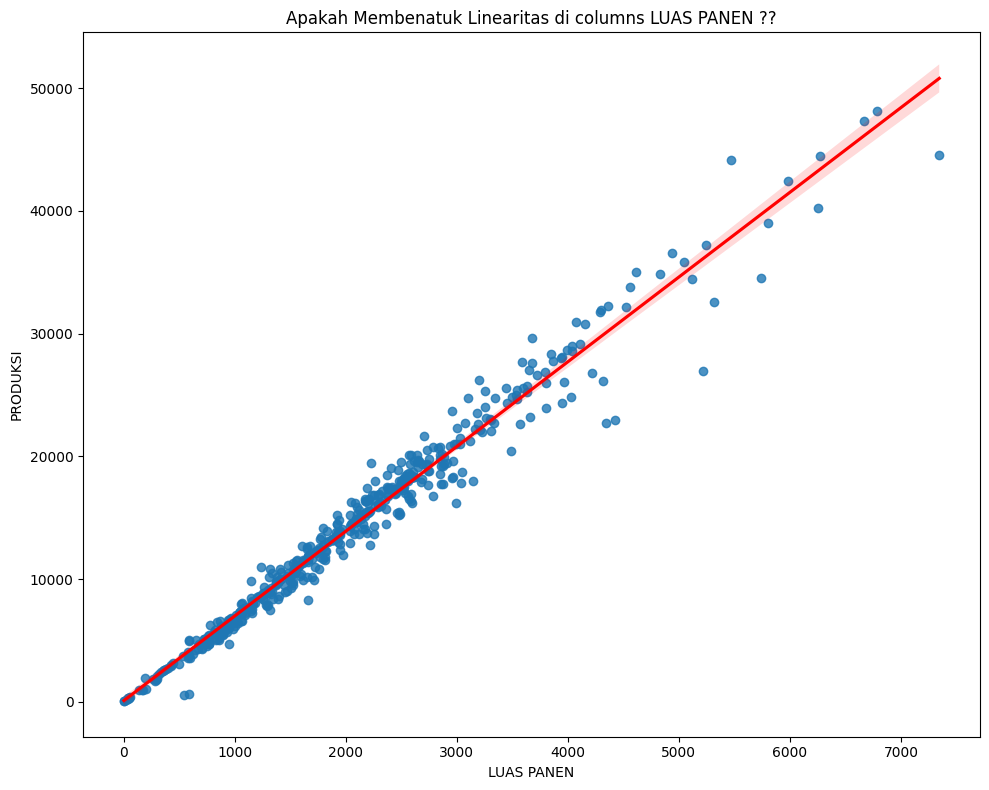

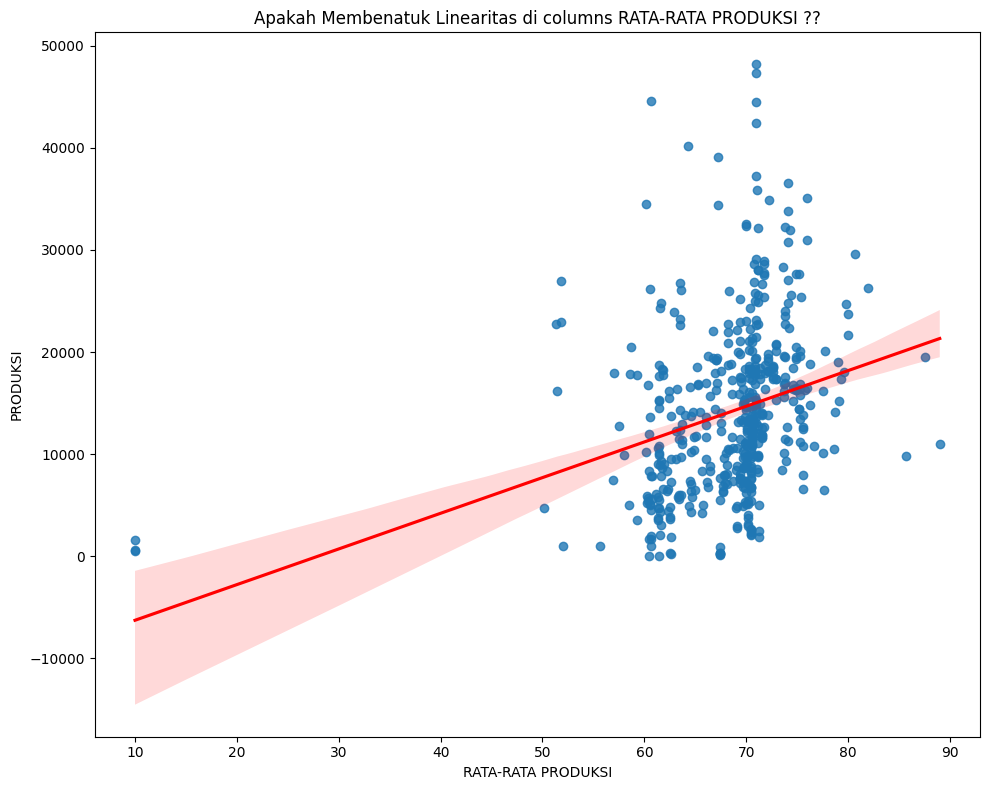

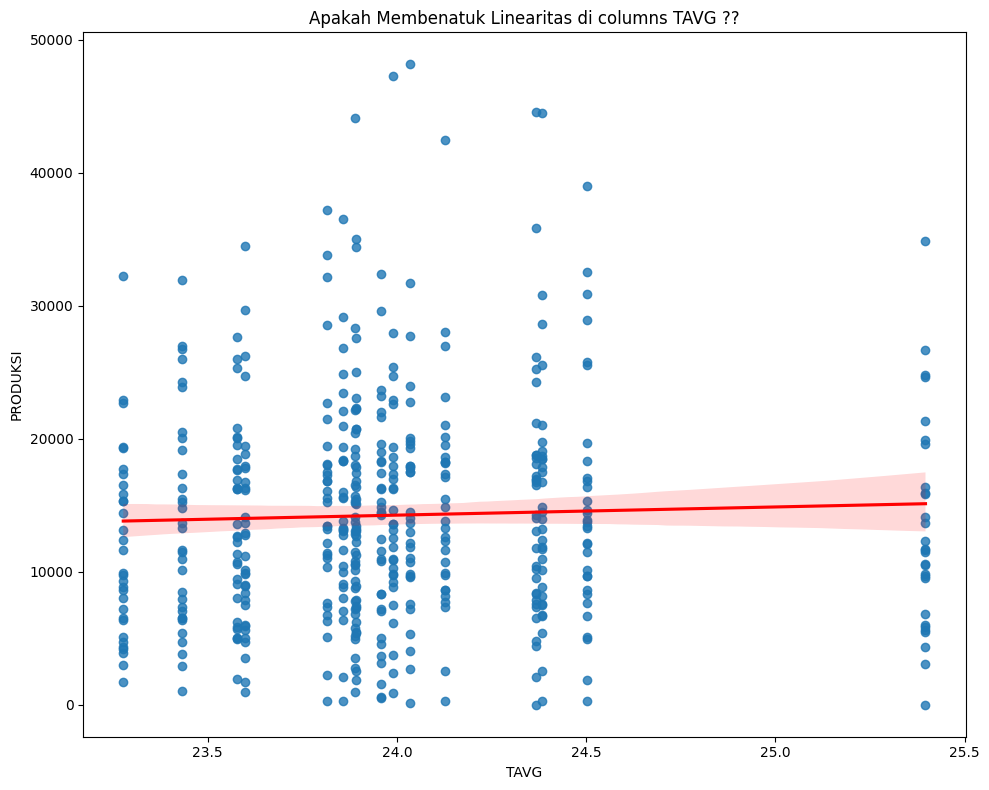

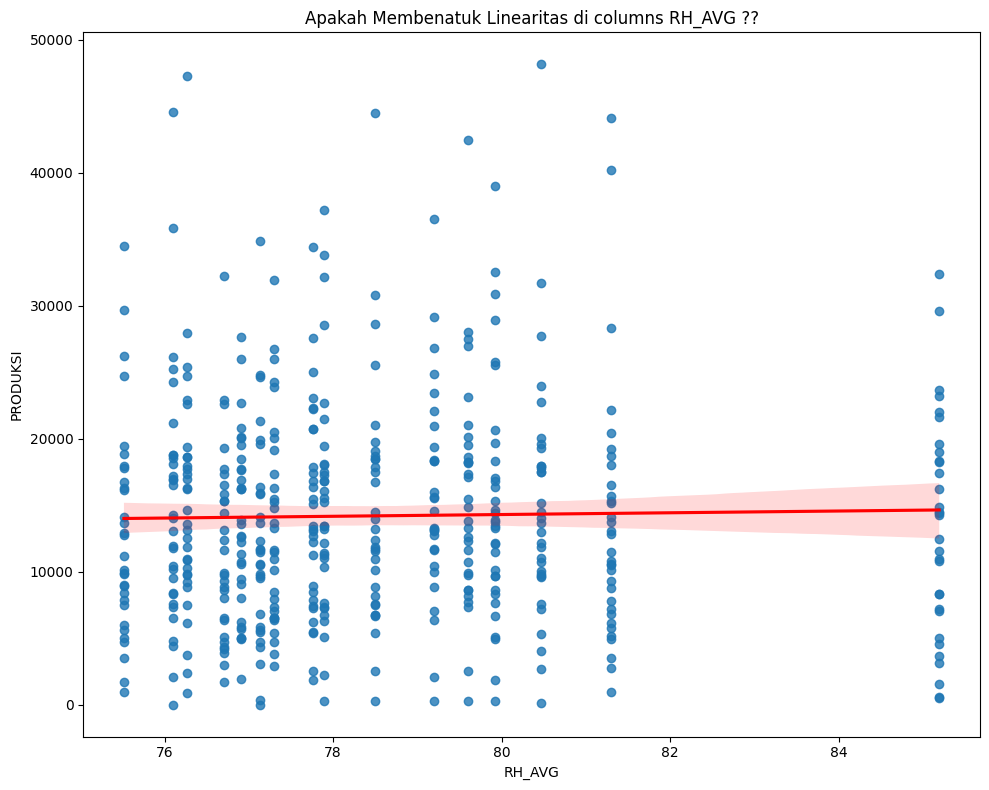

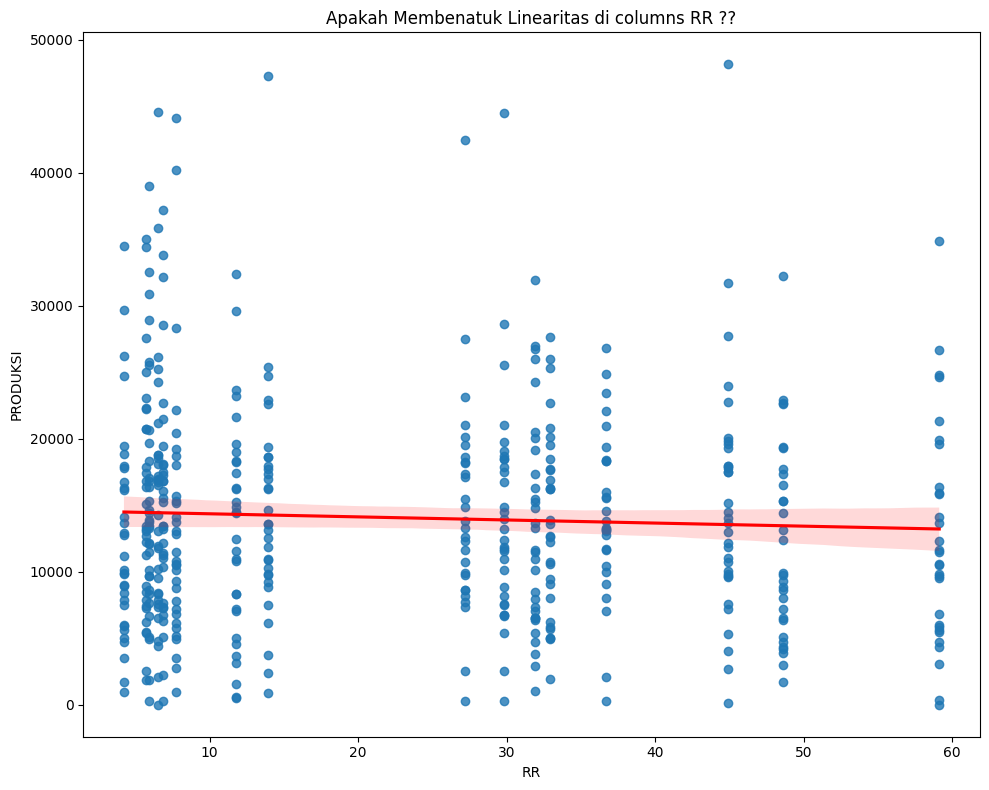

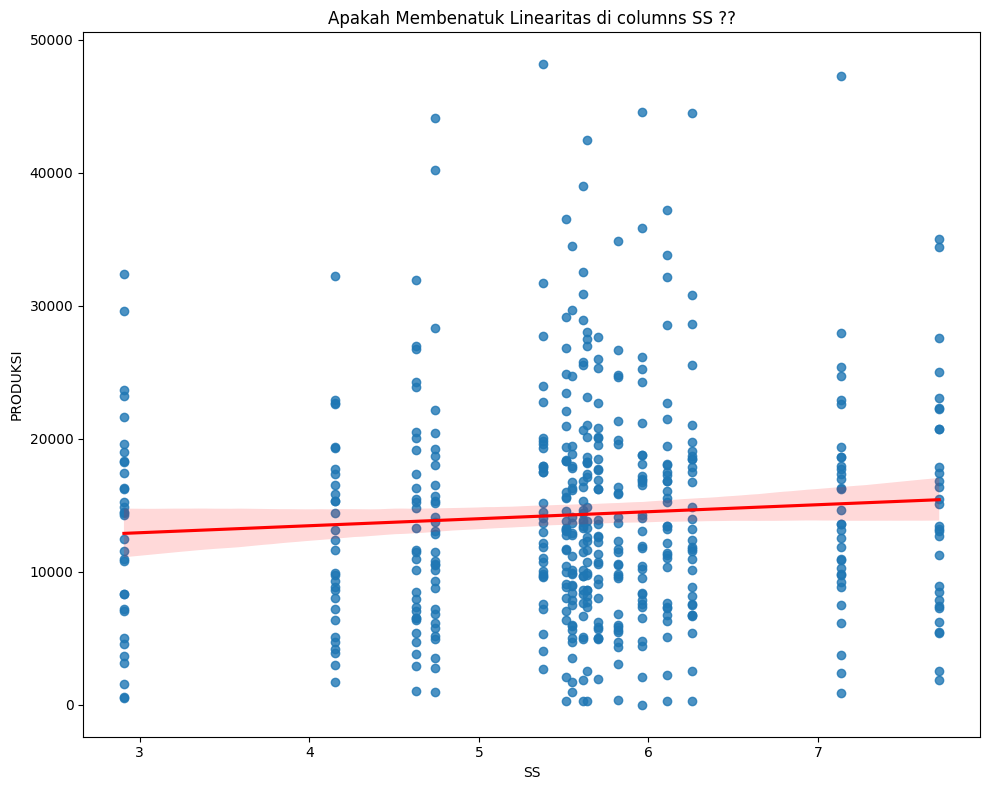

In [666]:
for col in num:
    if col != 'PRODUKSI':
        plt.figure(figsize=(10, 8))
        sns.regplot(df, x = col, y = 'PRODUKSI', line_kws={'color' : 'red'})
        plt.title(f"Apakah Membenatuk Linearitas di columns {col} ??")
        plt.tight_layout()
        plt.show()

#### Melihat Pengaruh Tahun dan Luas Lahan terhadap Hasil Panen

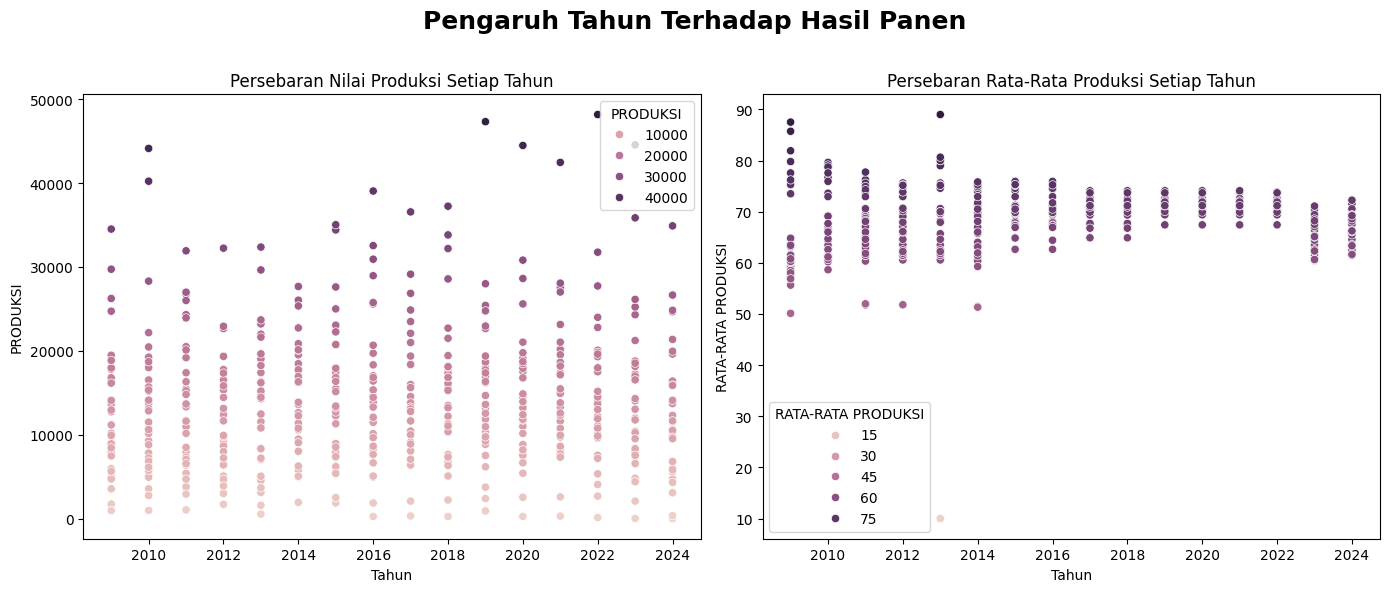

In [667]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(df, x='Tahun', y='PRODUKSI', hue='PRODUKSI', ax=axes[0])
axes[0].set_title('Persebaran Nilai Produksi Setiap Tahun')

sns.scatterplot(df, x='Tahun', y='RATA-RATA PRODUKSI', hue='RATA-RATA PRODUKSI', ax=axes[1])
axes[1].set_title('Persebaran Rata-Rata Produksi Setiap Tahun')

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.suptitle('Pengaruh Tahun Terhadap Hasil Panen', fontsize=18, fontweight='bold')
plt.show()

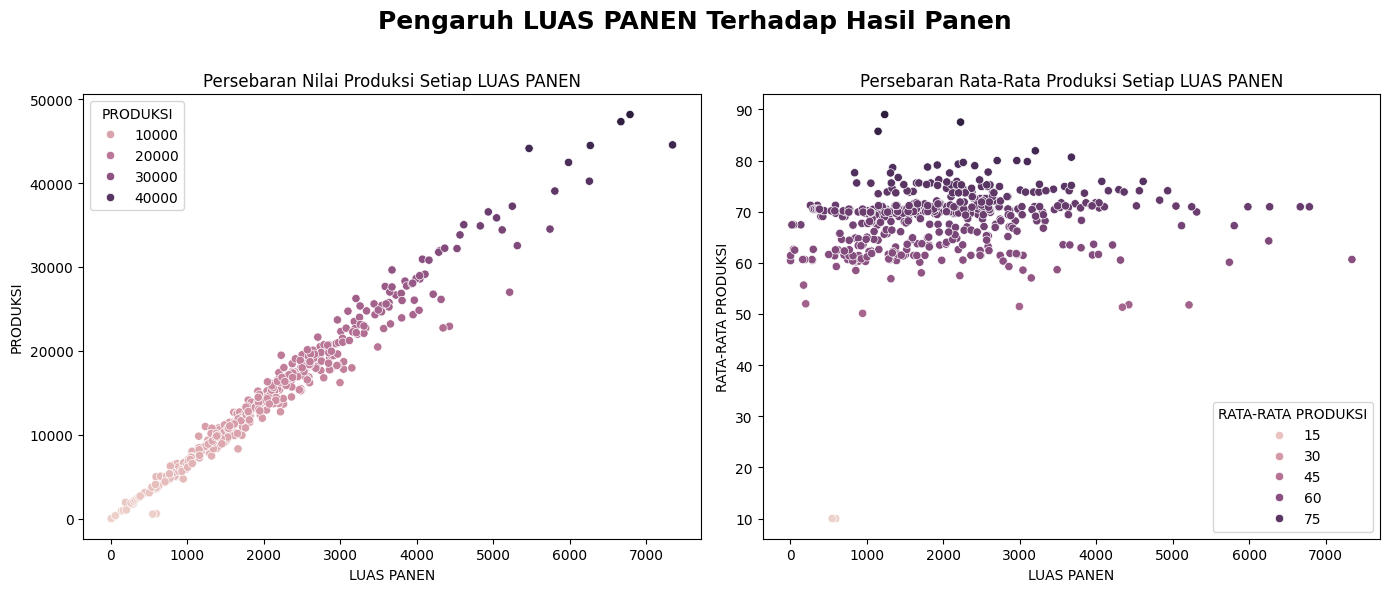

In [668]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(df, x='LUAS PANEN', y='PRODUKSI', hue='PRODUKSI', ax=axes[0])
axes[0].set_title('Persebaran Nilai Produksi Setiap LUAS PANEN')

sns.scatterplot(df, x='LUAS PANEN', y='RATA-RATA PRODUKSI', hue='RATA-RATA PRODUKSI', ax=axes[1])
axes[1].set_title('Persebaran Rata-Rata Produksi Setiap LUAS PANEN')

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.suptitle('Pengaruh LUAS PANEN Terhadap Hasil Panen', fontsize=18, fontweight='bold')
plt.show()

Berdasarkan grafik kiri, terlihat bahwa pada Tahun 2019 mengalami Breakthrough pada Hasil Panen, dimana Total Panen hampir menyentuh 50.000 Hektar, dan pada Tahun-Tahun selanjutnya Hasil Panen tertinggi berada di kisaran 40.000 - 50.000
Namun,
Berdasarkan grafik kanan, terlihat bahwa Sejak Tahun 2014, Rata-Rata Produksi Pangan / Panen terus menurun dan tidak mencapai angka 80 Hektar

#### Tren Tahunan Setiap Kolom

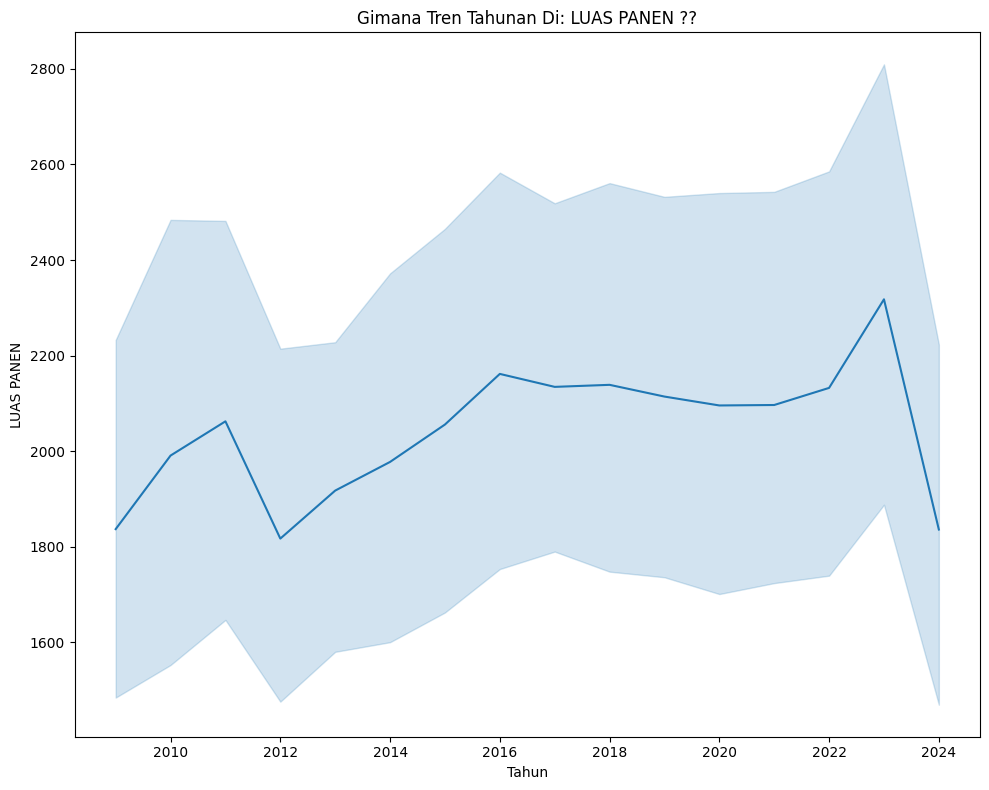

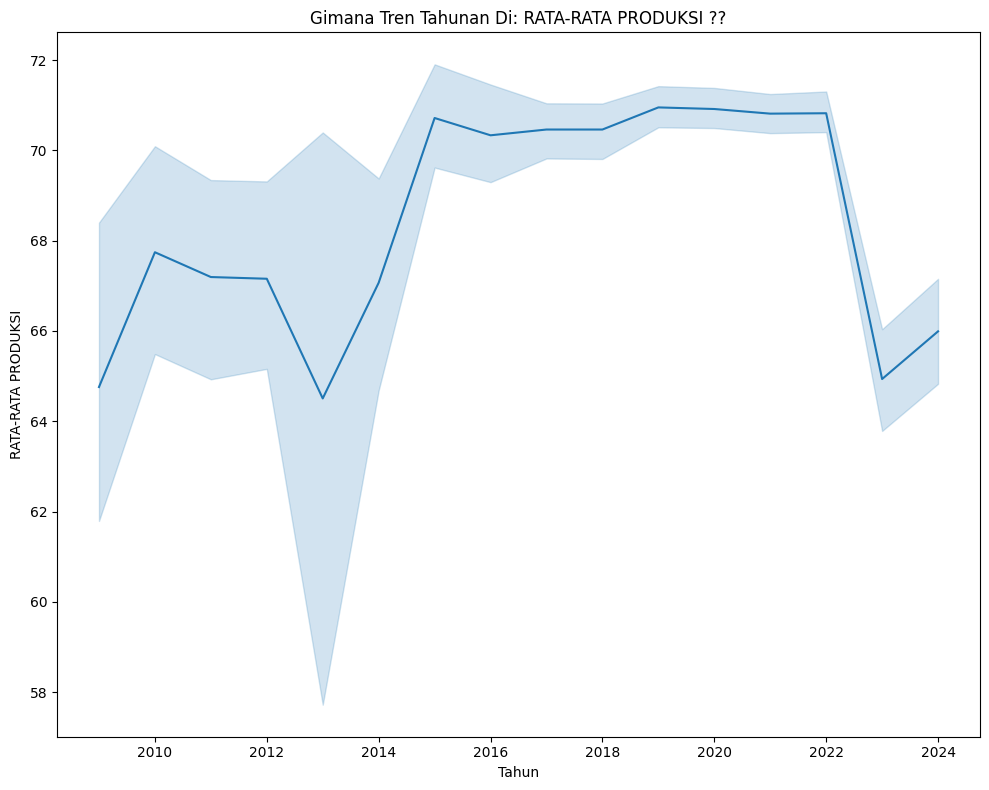

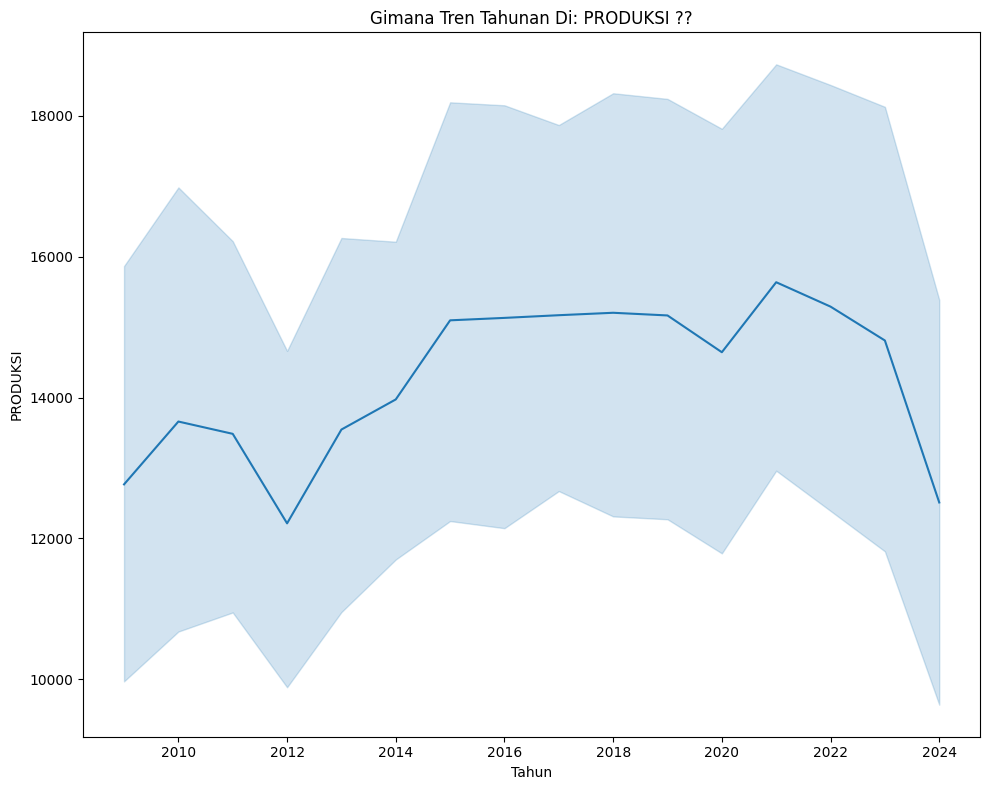

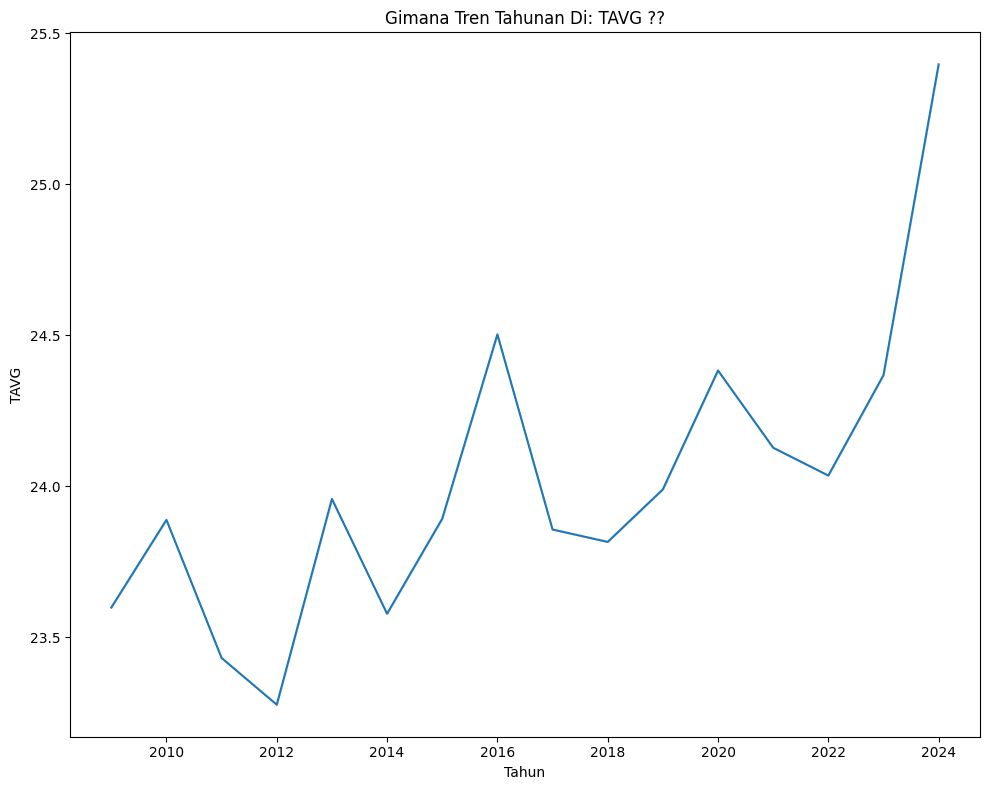

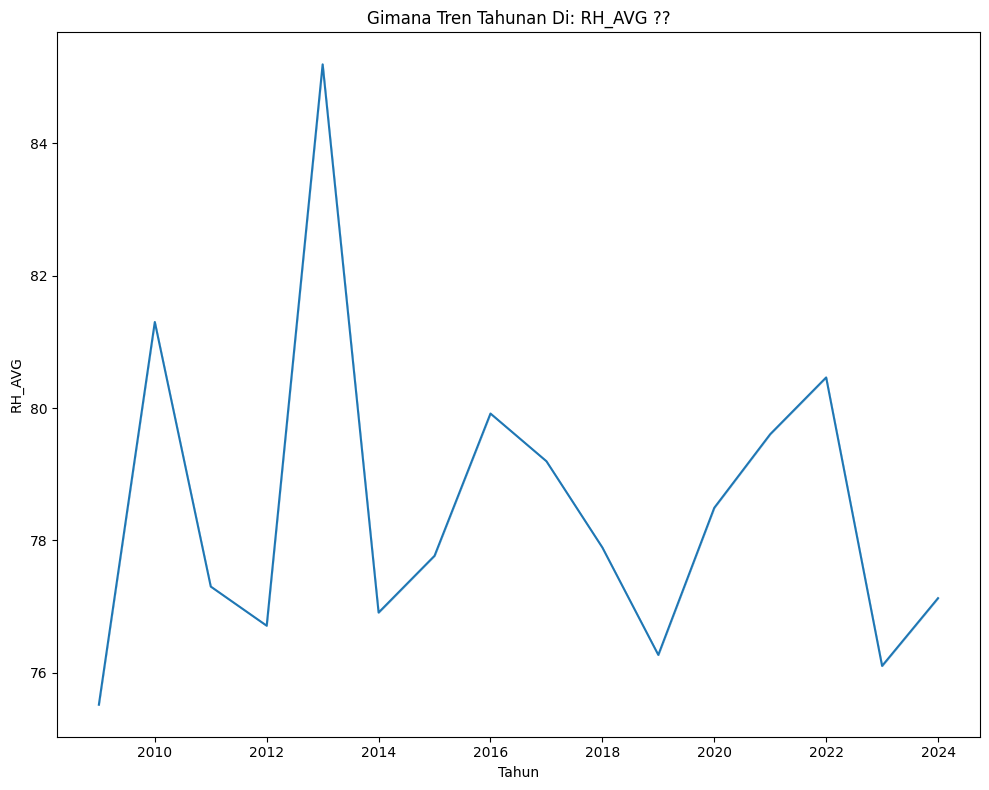

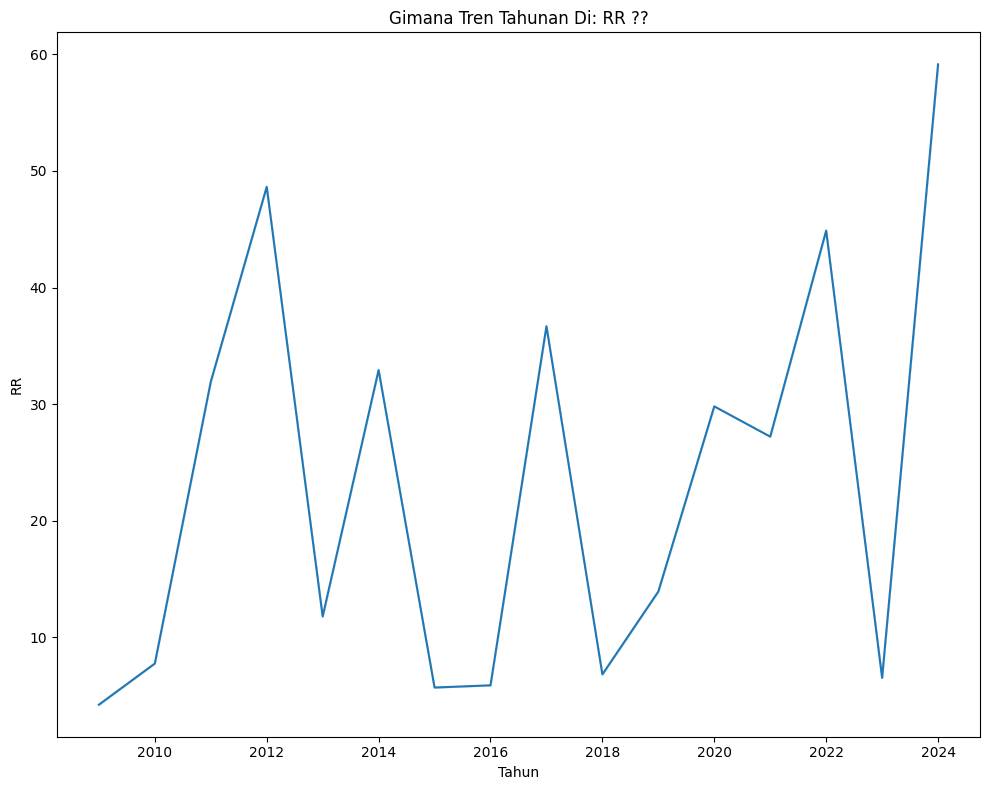

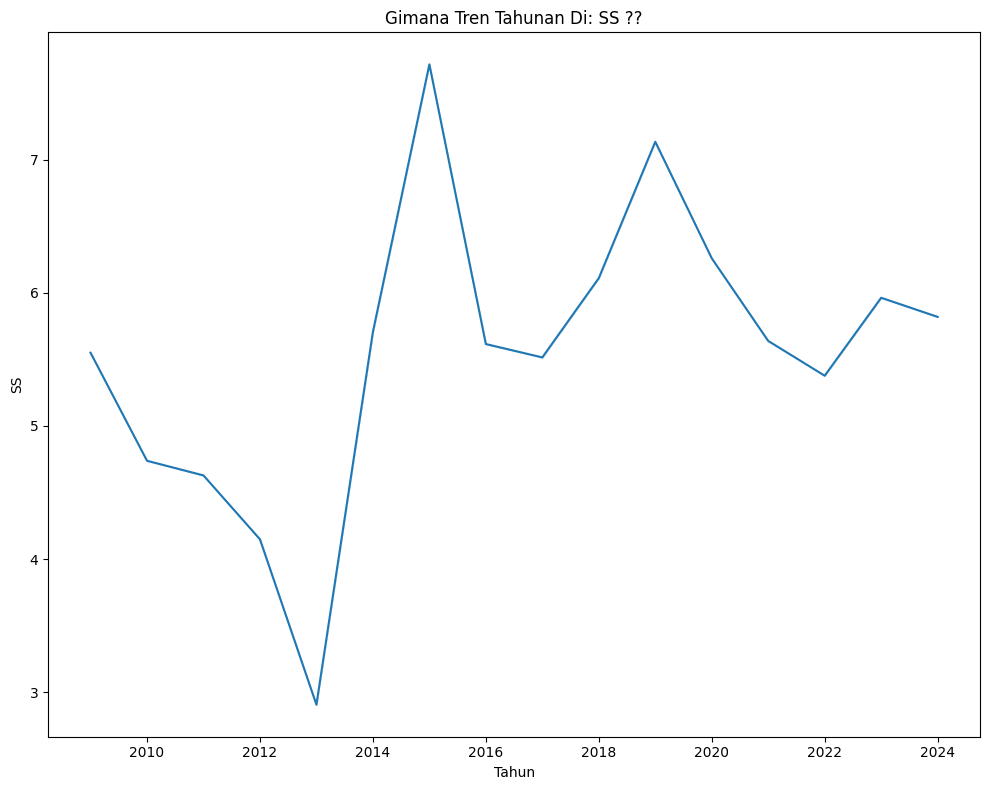

In [669]:
for col in num:
        if col != 'Tahun':
                plt.figure(figsize=(10, 8))
                sns.lineplot(df, x = 'Tahun', y = col)
                plt.title(f"Gimana Tren Tahunan Di: {col} ??")
                plt.tight_layout()
                plt.show()

### C.3 Multivariate Analysis

#### Korelasi Heatmap

<Axes: >

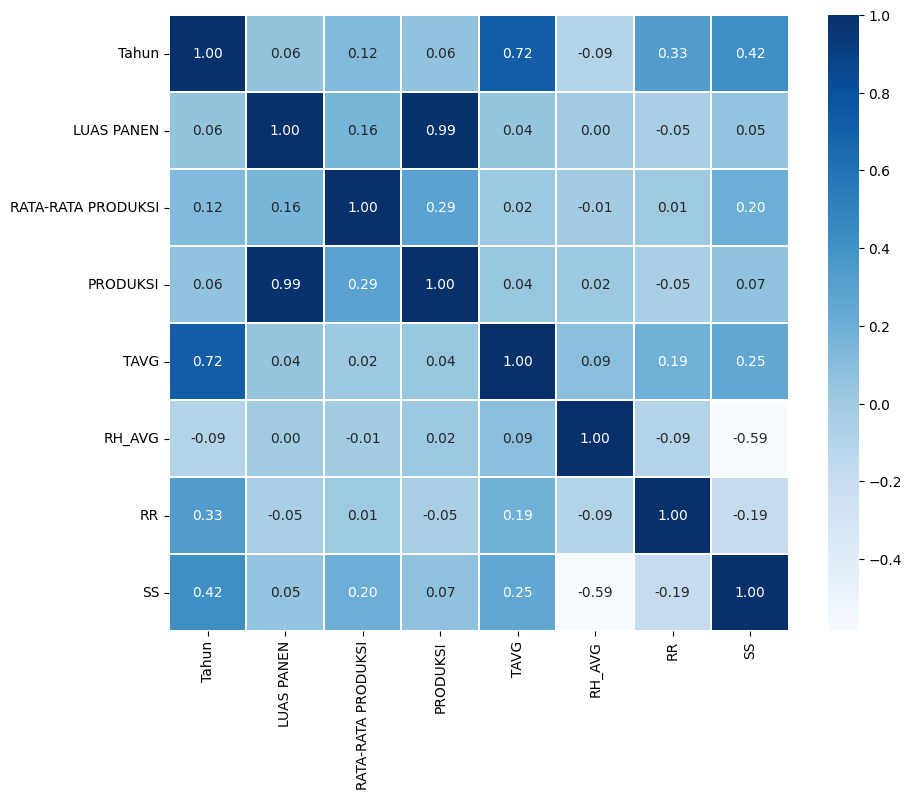

In [670]:
plt.figure(figsize=(10, 8))
sns.heatmap(num.corr(),
            annot = True,
            fmt = '.2f',
            cmap='Blues',
            linewidths=1.1)

### Insight Exploratory Data Analysis:
    1. Univariate Analysis:
    - Terdapat Outlier Namun Masih Dalam Batas Wajar
    - Skala Data Sangat Jauh Rentangnya
    - Kolom Panen dan Luas Tanah Sebagai Penentu Prediksi

    2. Bivariate Analysis:
    - Luas Panen sangat berpengaruh terhadap Hasil Panen (Korelasi Linear)
    - Total Hasil Panen mencapai puncak baru setiap tahun, namun Rata-Rata Panen berkurang tiap tahunnya
    - Kolom seperti Kecamatan, Temperature, Kelembapan, Curah Hujan, dan Lama Penyinaran Matahari tidak terlalu berpengaruh terhadap Total Hasil Panen

    3. Multivariate Analysis:
    - Fitur atau Kolom yang sangat berpengaruh pada Target Prediksi (Hasil Panen) yaitu Luas Panen

    Catatan Untuk Modelling:
    - Keep Nilai Anomali Karna Masih Batas Wajar
    - Disarankan Melakukan Scaling
    - Melakukan Log Untuk Mengtasi Skew
    - Bisa Menggunakan Simple dan Multiple
    - Jika Klasifikasi Menggunakan LPM untuk Threshold

## D. Modelling

### D.1 Mendefinisikan Variabel X (Fitur) dan y (Target)

In [671]:
X_data = df_clean.drop(columns=['Kecamatan', 'PRODUKSI', 'RATA-RATA PRODUKSI', 'Tahun'])
y_data = df_clean['PRODUKSI'].values.reshape(-1, 1)

### D.2 Split Data Train dan Data Test (80 : 20)

In [672]:
np.random.seed(42)
indices = np.random.permutation(len(X_data))
test_size = int(len(X_data) * 0.2)

train_idx = indices[test_size:]
test_idx = indices[:test_size]

X_train, X_test = X_data.iloc[train_idx], X_data.iloc[test_idx]
y_train, y_test = y_data[train_idx], y_data[test_idx]

In [673]:
print(f'Train Data: {len(X_train)}')
print(f'Test Data: {len(X_test)}')

Train Data: 323
Test Data: 80


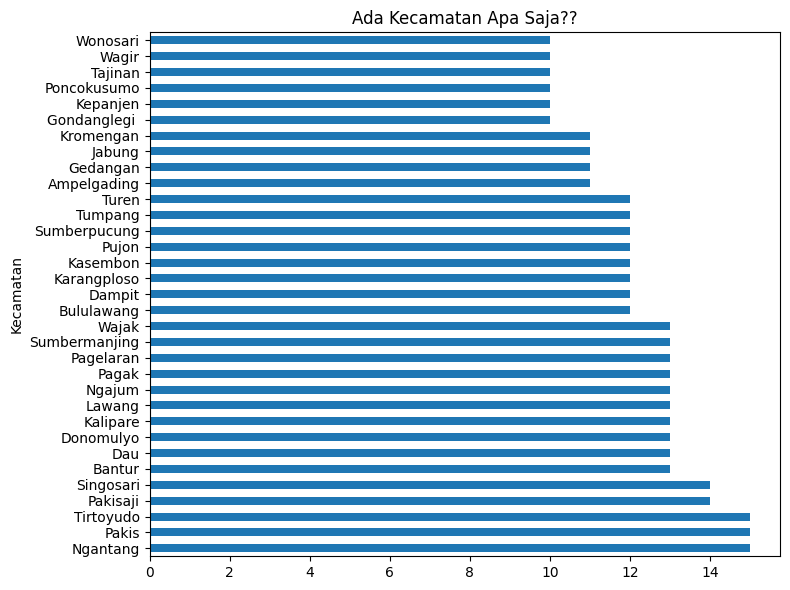

In [674]:
plt.figure(figsize=(8, 6))
df_clean['Kecamatan'].value_counts(ascending=False).plot(kind='barh')
plt.title("Ada Kecamatan Apa Saja??")
plt.tight_layout()
plt.show()

### D.3 Feature Scaling

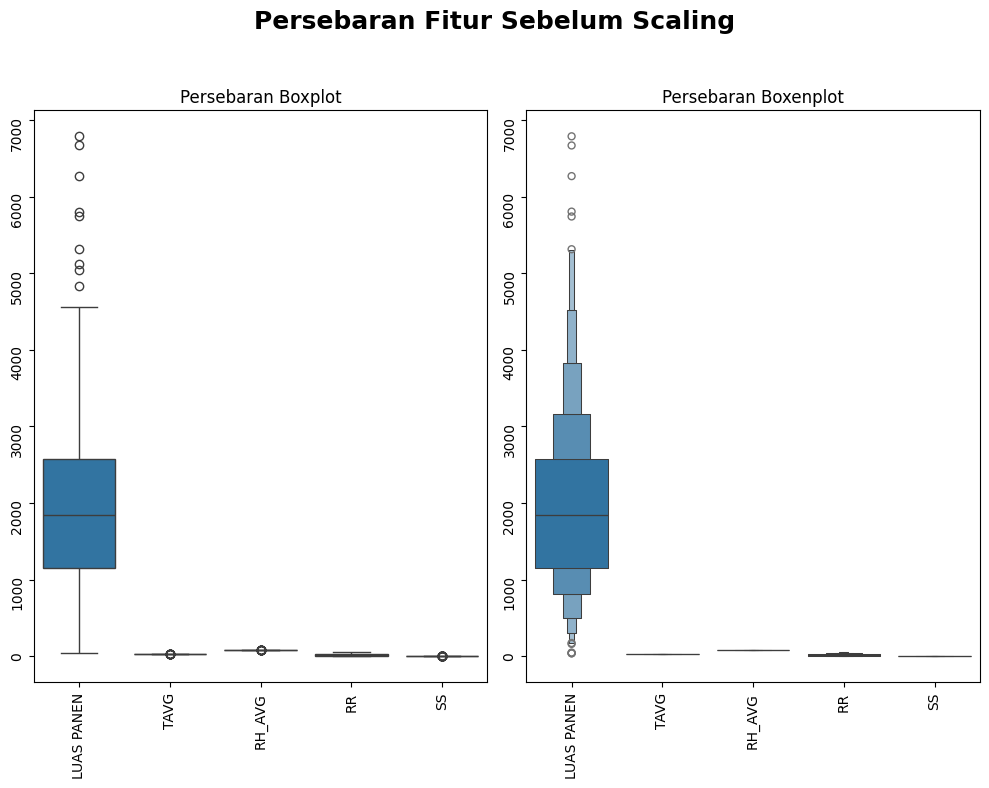

In [675]:
fig, axes = plt.subplots(1, 2, figsize=(10, 8))
sns.boxplot(X_train, ax=axes[0])
axes[0].set_title('Persebaran Boxplot')
axes[0].tick_params(rotation=90)

sns.boxenplot(X_train, ax=axes[1])
axes[1].set_title('Persebaran Boxenplot')
axes[1].tick_params(rotation=90)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.suptitle('Persebaran Fitur Sebelum Scaling', fontsize=18, fontweight='bold')
plt.show()

#### Standard Scaler (Standarisasi)

In [676]:
X_train_mean = X_train.mean(axis=0)
X_train_std = X_train.std(axis=0)

X_train_standard_scale = (X_train - X_train_mean) / X_train_std
X_test_standard_scale = (X_test - X_train_mean) / X_train_std

#### MinMax Scaler (Normalisasi)

In [677]:
X_train_min = X_train.min(axis=0)
X_train_max = X_train.max(axis=0)

X_train_minmax_scale = (X_train - X_train_min) / (X_train_max - X_train_min)
X_test_minmax_scale = (X_test - X_train_min) / (X_train_max - X_train_min)

#### Robust Scaler

In [678]:
X_train_median = X_train.median(axis=0)
Q1 = X_train.quantile(0.25, axis=0)
Q3 = X_train.quantile(0.75, axis=0)
IQR = Q3 - Q1
IQR[IQR == 0] = 1

X_train_robust_scale = (X_train - X_train_median) / IQR
X_test_robust_scale = (X_test - X_train_median) / IQR

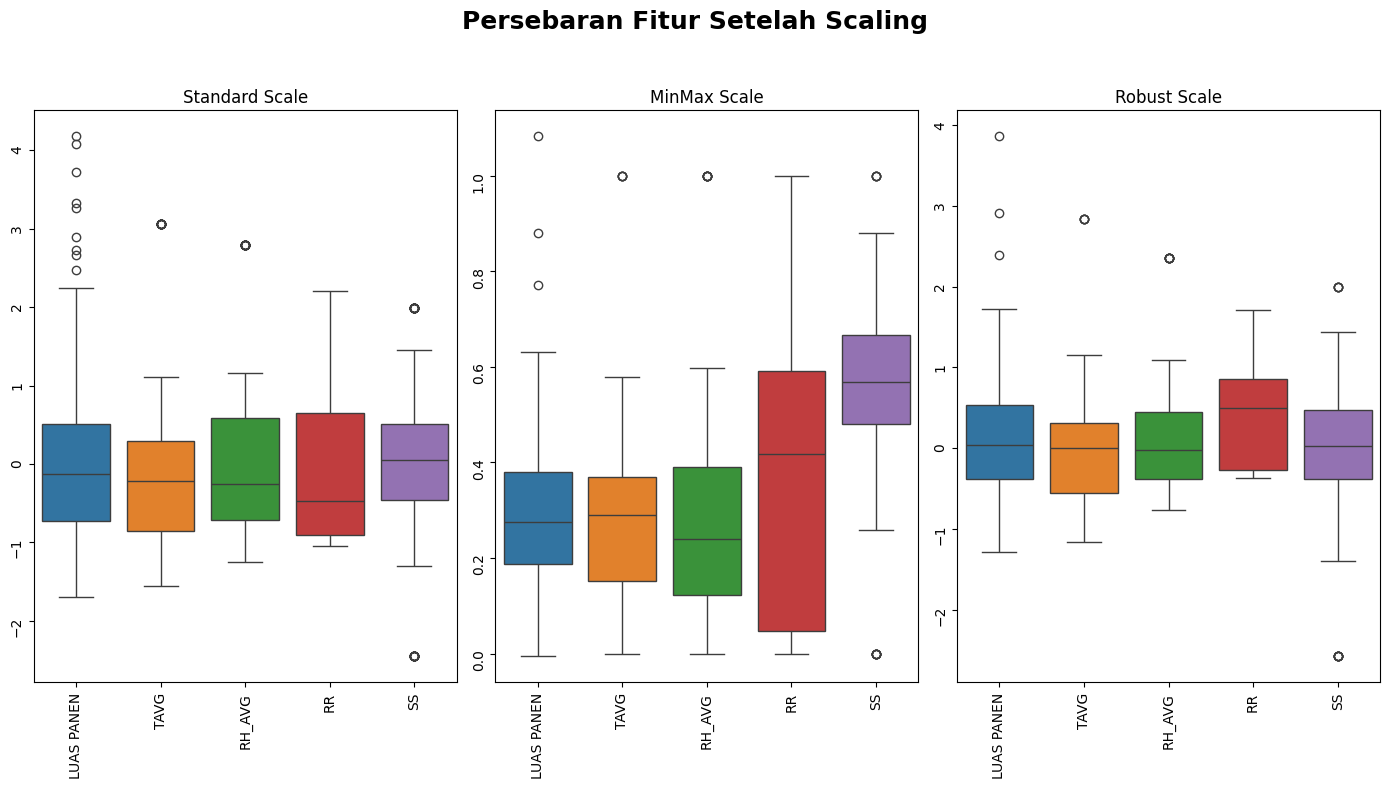

In [679]:
fig, axes = plt.subplots(1, 3, figsize=(14, 8))
sns.boxplot(X_train_standard_scale, ax=axes[0])
axes[0].set_title('Standard Scale')
axes[0].tick_params(rotation=90)

sns.boxplot(X_test_minmax_scale, ax=axes[1])
axes[1].set_title('MinMax Scale')
axes[1].tick_params(rotation=90)

sns.boxplot(X_test_robust_scale, ax=axes[2])
axes[2].set_title('Robust Scale')
axes[2].tick_params(rotation=90)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.suptitle('Persebaran Fitur Setelah Scaling', fontsize=18, fontweight='bold')
plt.show()

### D.4 Modifikasi Matriks (Tambah Bias)

In [680]:
ones_train = np.ones((len(X_train_minmax_scale), 1))
ones_test = np.ones((len(X_test_minmax_scale), 1))

X_train = np.concatenate((ones_train, X_train_minmax_scale), axis=1)
X_test = np.concatenate((ones_test, X_test_minmax_scale), axis=1)

### D.5 Ordinary Least Squares & Ridge Regression Model

In [681]:
def train_ols_ridge(X, y, lamda=0 ):
    m, n = X.shape
    I = np.eye(n)
    I[0, 0] = 0

    matrix_core = (X.T @ X) + (lamda * I)
    theta = np.linalg.pinv(matrix_core) @ X.T @ y
    return theta

def evaluate_model(X, y_true, theta, model_name = 'Model'):
    y_pred = X @ theta

    # Error Metrics
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))

    # R2 Score
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    return {
        'Model' : model_name,
        'MAE' : mae,
        'RMSE' : rmse,
        'R2 Score' : r2
    }

### D.6 Perbandingan Model OLS dan Ridge

In [682]:
results = []
thetas = {}

theta_ols = train_ols_ridge(X_train, y_train, lamda=0)
result_ols = evaluate_model(X_test, y_test, theta_ols, 'OLS (Standard)')
results.append(result_ols)
thetas['OLS'] = theta_ols

theta_ridge1 = train_ols_ridge(X_train, y_train, lamda=1.0)
result_ridge1 = evaluate_model(X_test, y_test, theta_ridge1, 'Ridge (Lamda = 1)')
results.append(result_ridge1)
thetas['Ridge_1'] = theta_ridge1

theta_ridge10 = train_ols_ridge(X_train, y_train, lamda=10.0)
result_ridge10 = evaluate_model(X_test, y_test, theta_ridge10, 'Ridge (Lamda = 10)')
results.append(result_ridge10)
thetas['Ridge_10'] = theta_ridge10

df_results = pd.DataFrame(results)
df_results

,Model,MAE,RMSE,R2 Score
0,OLS (Standard),789.571623,1288.269808,0.978515
1,Ridge (Lamda = 1),1102.731063,1467.328620,0.972128
2,Ridge (Lamda = 10),3451.049641,4637.945348,0.721538


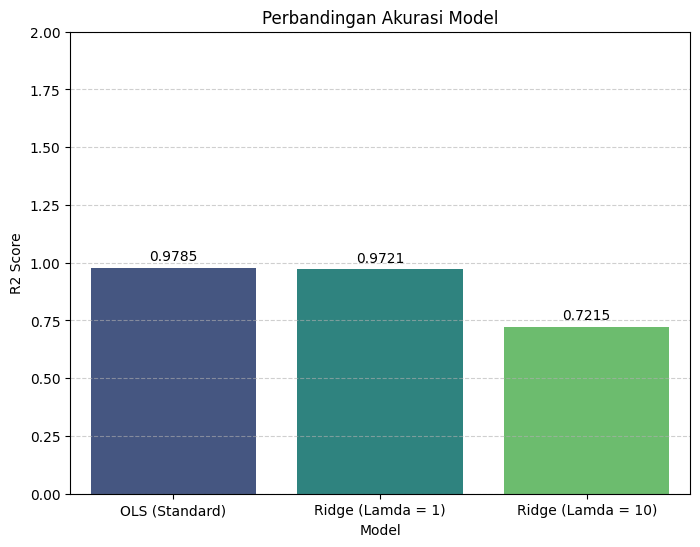

In [683]:
plt.figure(figsize=(8, 6))
ax = sns.barplot(df_results, x='Model', y='R2 Score', hue='Model', palette='viridis')
plt.title('Perbandingan Akurasi Model')
plt.ylim(0, 2)
plt.grid(axis='y', alpha=0.6, linestyle='--')
for containers in ax.containers:
    ax.bar_label(containers, fmt='%.4f', padding=3)
plt.show()

### D.7 Feature Importance

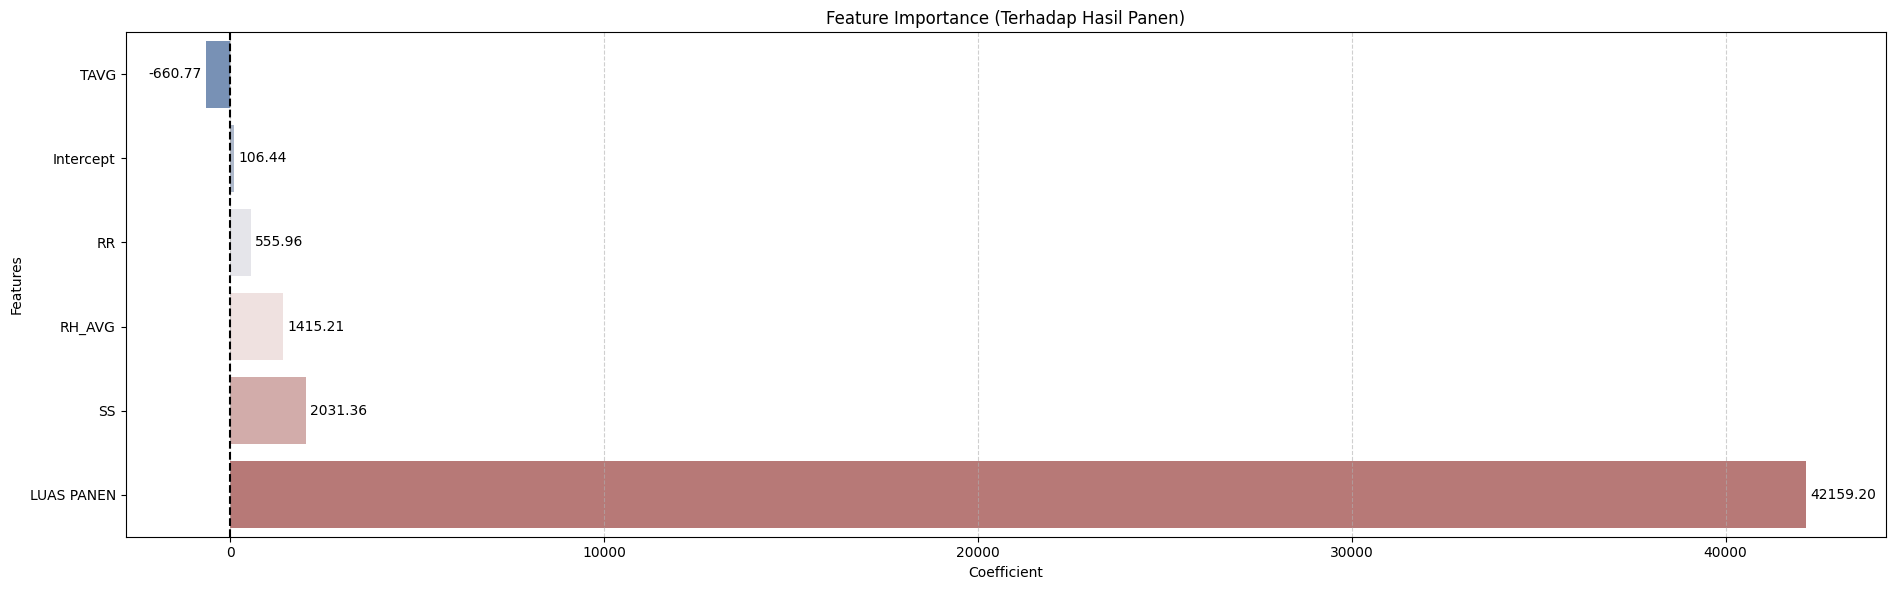

----- Rumus Prediksi -----
Rumus Hasil Panen: 106.44 + (42159.20 * LUAS PANEN) + (-660.77 * TAVG) + (1415.21 * RH_AVG) + (555.96 * RR) + (2031.36 * SS)


In [684]:
features_list = ['Intercept'] + df.drop(columns=['Kecamatan', 'Tahun', 'RATA-RATA PRODUKSI', 'PRODUKSI']).columns.tolist()
coefs = theta_ridge1.flatten()

df_coefs = pd.DataFrame({
    'Features' : features_list,
    'Coefficient' : coefs
})
df_coefs = df_coefs.sort_values(by='Coefficient')

plt.figure(figsize=(16, 6))
ax = sns.barplot(df_coefs, x='Coefficient', y='Features', hue='Features', palette='vlag')
plt.title('Feature Importance (Terhadap Hasil Panen)')
plt.axvline(0, color='black', linestyle='--')
plt.grid(axis='x', alpha=0.6, linestyle='--')
for containers in ax.containers:
    ax.bar_label(containers, fmt='%.2f', padding=3)

plt.tight_layout(rect=[0, 0, 1.2, 1])
plt.show()

print('----- Rumus Prediksi -----')
intercept = coefs[0]
sisa_coef = coefs[1:]
sisa_nama = features_list[1:]
rumus = (f'({val:.2f} * {name})' for val, name in zip(sisa_coef, sisa_nama))
print(f'Rumus Hasil Panen: {intercept:.2f} + ' + ' + '.join(rumus))

### D.8 Prediksi Menggunakan Model Terbaik

In [685]:
test_predictions = X_test @ theta_ols
train_predictions = X_train @ theta_ols

## E. Evaluasi Regresi

### E.1 Error Model

In [686]:
error_test = y_test - test_predictions
error_train = y_train - train_predictions

df_error_test = pd.DataFrame(error_test)
df_error_train = pd.DataFrame(error_train)

#### Error Test

In [687]:
df_error_test.columns = ['Error']
df_error_test.head()

,Error
0,-242.032350
1,-2801.284042
2,-1909.150971
3,835.036978
4,-4.541449


#### Error Train

In [688]:
df_error_train.columns = ['Error']
df_error_train.head()

,Error
0,434.819229
1,-193.284850
2,855.381384
3,2262.089462
4,-3040.555633


### E.2 Mean Squared Errors (MSE)

#### Test MSE

In [689]:
test_mse = np.mean(error_test ** 2)
print(f'MSE (Test): {test_mse:.2f}')

MSE (Test): 1659639.10


#### Train MSE

In [690]:
train_mse = np.mean(error_train ** 2)
print(f'MSE (Train): {train_mse:.2f}')

MSE (Train): 1466834.10


### E.3 Root Mean Squared Errors (RMSE)

#### Test RMSE

In [691]:
test_rmse = np.sqrt(test_mse)
print(f'RMSE (Test): {test_rmse:.2f}')

RMSE (Test): 1288.27


#### Train RMSE

In [692]:
train_rmse = np.sqrt(train_mse)
print(f'RMSE (Train): {train_rmse:.2f}')

RMSE (Train): 1211.13


### E.4 Mean Absolute Error (MAE)

#### Test MAE

In [693]:
test_mae = np.mean(np.abs(error_test))
print(f'MAE (Test): {test_mae:.2f}')

MAE (Test): 789.57


#### Train MAE

In [694]:
train_mae = np.mean(np.abs(error_train))
print(f'MAE (Train): {train_mae:.2f}')

MAE (Train): 772.13


### E.5 R-Squared (Akurasi)

#### Test R-Squared

In [695]:
test_ss_res = np.sum((y_test - test_predictions) ** 2)
test_ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
test_r2 = 1 - (test_ss_res / test_ss_tot)
print(f'R2 Score (Test): {test_r2:.4f}')

R2 Score (Test): 0.9785


#### Train R-Squared

In [696]:
train_ss_res = np.sum((y_train - train_predictions) ** 2)
train_ss_tot = np.sum((y_train - np.mean(y_train)) ** 2)
train_r2 = 1 - (train_ss_res / train_ss_tot)
print(f'R2 Score (Train): {train_r2:.4f}')

R2 Score (Train): 0.9774


### E.6 Adjusted R-Squared (Akurasi)

#### Test Adjusted R-Squared

In [697]:
test_n = len(X_test)
test_p = X_test.shape[1] - 1
test_adj_r2 = 1 - ((1 - test_r2) * (test_n - 1) / (test_n - test_p - 1))
print(f'Adjusted R2 Score (Test): {test_adj_r2:.4f}')

Adjusted R2 Score (Test): 0.9771


#### Train Adjusted R-Squared

In [698]:
train_n = len(X_train)
train_p = X_train.shape[1] - 1
train_adj_r2 = 1 - ((1 - train_r2) * (train_n - 1) / (train_n - train_p - 1))
print(f'Adjusted R2 Score (Train): {train_adj_r2:.4f}')

Adjusted R2 Score (Train): 0.9770


### E.7 Visualisasi Prediksi Model

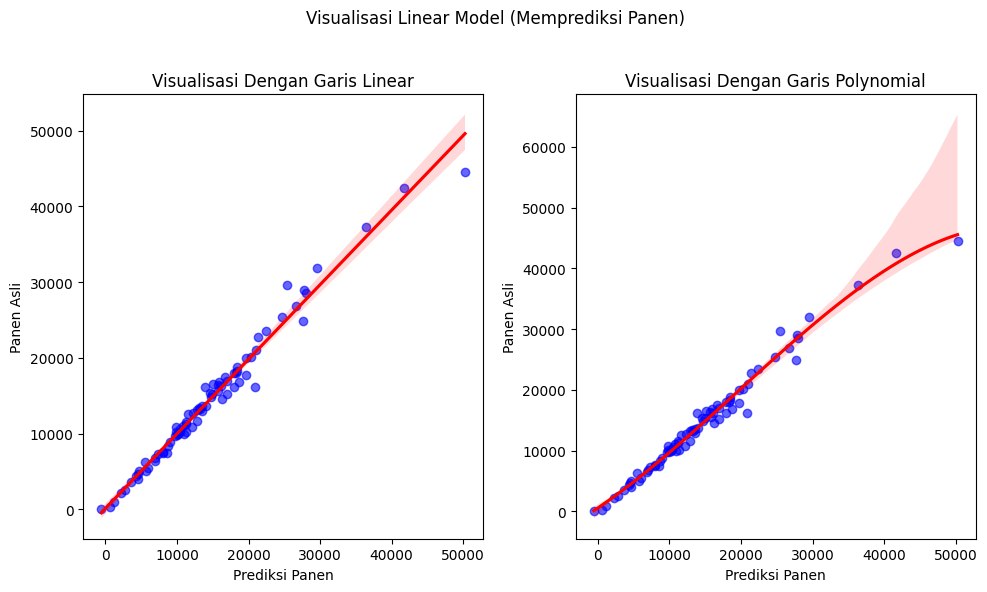

In [699]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
sns.regplot(x=test_predictions, y=y_test, ax=axes[0], color='blue', line_kws={'color' : 'red'}, scatter_kws={'alpha' : 0.6}, order=1)
axes[0].set_title('Visualisasi Dengan Garis Linear')
axes[0].set_xlabel('Prediksi Panen')
axes[0].set_ylabel('Panen Asli')

sns.regplot(x=test_predictions, y=y_test, ax=axes[1], color='blue', line_kws={'color' : 'red'}, scatter_kws={'alpha' : 0.6}, order=3)
axes[1].set_title('Visualisasi Dengan Garis Polynomial')
axes[1].set_xlabel('Prediksi Panen')
axes[1].set_ylabel('Panen Asli')

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.suptitle('Visualisasi Linear Model (Memprediksi Panen)')
plt.show()

### E.8 Residu dan Normalitas Data Residu

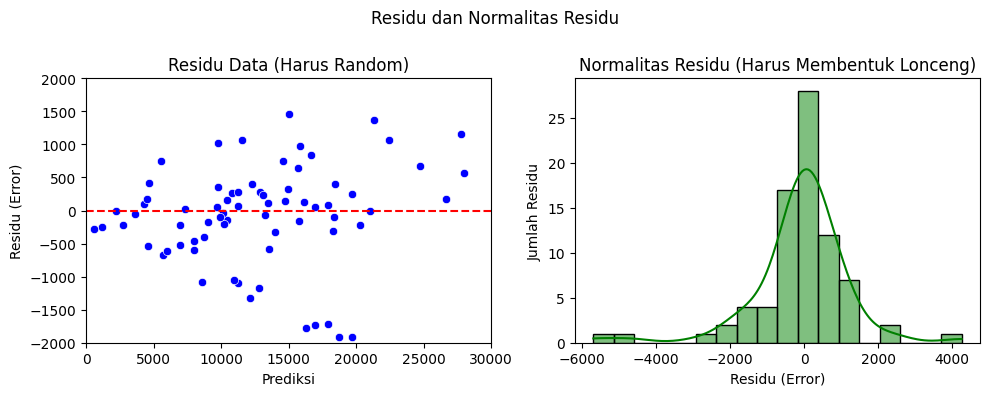

In [700]:
residuals = y_test - test_predictions
residuals_flat = residuals.flatten()
test_predictions_flat = test_predictions.flatten()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.scatterplot(x=test_predictions_flat, y=residuals_flat, ax=axes[0], color='blue')
axes[0].set_title('Residu Data (Harus Random)')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Residu (Error)')
axes[0].set_ylim(-2000, 2000)
axes[0].set_xlim(0, 30000)
axes[0].axhline(color='red', linestyle='--')

sns.histplot(residuals_flat, kde=True, color='green', ax=axes[1])
axes[1].set_title('Normalitas Residu (Harus Membentuk Lonceng)')
axes[1].set_xlabel('Residu (Error)')
axes[1].set_ylabel('Jumlah Residu')

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.suptitle('Residu dan Normalitas Residu')
plt.show()

## F. Evaluasi Klasifikasi

### F.1 Confusion Matrix

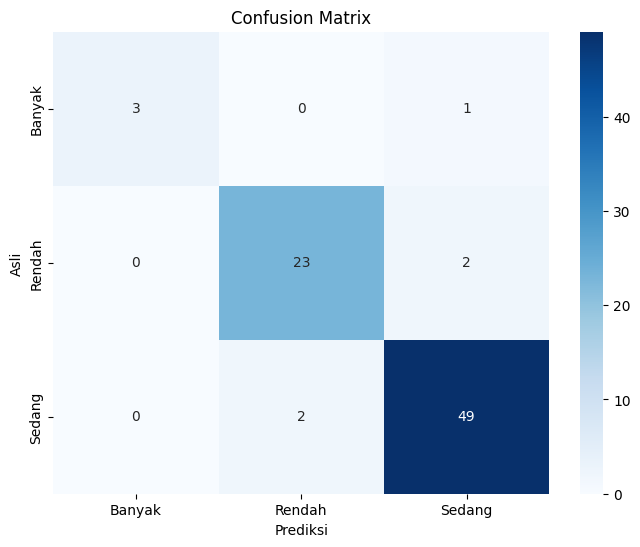

Class: Banyak
True Positives: 3
False Positives: 0
False Negatives: 1
True Negatives: 76
Class: Rendah
True Positives: 23
False Positives: 2
False Negatives: 2
True Negatives: 53
Class: Sedang
True Positives: 49
False Positives: 3
False Negatives: 2
True Negatives: 26
Akurasi Klasifikasi: 93.75%


In [701]:
def categorize_panen(panen):
    if panen < 10000: return 'Rendah'
    elif panen < 30000: return 'Sedang'
    else: return 'Banyak'

v_cat = np.vectorize(categorize_panen)
y_test_cat = v_cat(y_test).flatten()
y_pred_cat = v_cat(test_predictions).flatten()

confusion_matrix = pd.crosstab(y_test_cat, y_pred_cat, rownames=['Asli'], colnames=['Prediksi'])
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, cmap='Blues', fmt='d')
plt.title('Confusion Matrix')
plt.show()

cm_array = confusion_matrix.values
TP = np.diag(cm_array)
FP = np.sum(cm_array, axis=0) - TP
FN = np.sum(cm_array, axis=1) - TP
TN = np.sum(cm_array) - (TP + FP + FN)

class_name = confusion_matrix.index
for i, name in enumerate(class_name):
    print(f'Class: {name}')
    print(f'True Positives: {TP[i]}')
    print(f'False Positives: {FP[i]}')
    print(f'False Negatives: {FN[i]}')
    print(f'True Negatives: {TN[i]}')
    print('='*20)

accuracy = np.trace(cm_array) / np.sum(cm_array)
print(f'Akurasi Klasifikasi: {accuracy * 100:.2f}%')

<Axes: >

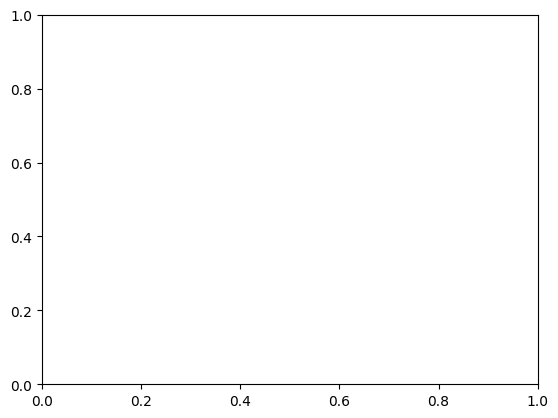

In [702]:
sns.barplot()

### F.2 Precision


In [703]:
precision = np.mean(TP / (TP + FP))
print(f'Precision: {precision:.2f}')

Precision: 0.95


### F.3 Recall

In [704]:
recall = np.mean(TP / (TP + FN))
print(f'Recall: {recall:.2f}')

Recall: 0.88


### F.4 F-1 Score

In [705]:
f1_score = 2 * (precision * recall) / (precision + recall)
print(f'F-1 Score: {f1_score:.2f}')

F-1 Score: 0.91


## G. GUI

### G.1 Tkinter

In [ ]:
import tkinter as tk
from tkinter import *
from tkinter import messagebox
from tkinter import filedialog
from pandas import *

INTERCEPT = theta_ols[0][0]
SLOPE = theta_ols[1:]
VAL_DEFAULT = df_clean.drop(columns=['Kecamatan', 'Tahun', 'RATA-RATA PRODUKSI', 'PRODUKSI']).mean().values

def predict():
    try:
        input_luas_panen = float(luas_panen.get())
        full_input = np.copy(VAL_DEFAULT)
        full_input[0] = input_luas_panen
        input_scaled = (full_input - X_train_min) / (X_train_max - X_train_min)
        hasil_panen = INTERCEPT + np.dot(input_scaled, SLOPE)
        hasil_panen_fix = hasil_panen.item()
        kategori_panen = 'Sedikit' if hasil_panen_fix < 10000 else ('Sedang' if hasil_panen_fix < 30000 else 'Banyak')
        Hasil.config(text=f'Hasil Produksi (Panen) : {hasil_panen_fix:.0f}\nHasil Kategori (Panen): {kategori_panen}')
    except Exception as e:
        messagebox.showerror('Error', f'Terjadi Kesalahan: {e}')

def predict_batch():
    try:
        filepath = filedialog.askopenfilename(filetypes=[('CSV Files', '*.csv')])
        if not filepath: return
        df = pd.read_csv(filepath)
        hasil_prediksi = []
        hasil_kategori = []

        for i, row in df.iterrows():
            input_luas_panen = row['LUAS PANEN']
            full_input = np.copy(VAL_DEFAULT)
            full_input[0] = input_luas_panen
            input_scaled = (full_input - X_train_min) / (X_train_max - X_train_min)
            hasil_panen = INTERCEPT + np.dot(input_scaled, SLOPE)
            hasil_panen_fix = hasil_panen.item()
            kategori_panen = 'Sedikit' if hasil_panen_fix < 10000 else ('Sedang' if hasil_panen_fix < 30000 else 'Banyak')
            hasil_prediksi.append(hasil_panen_fix)
            hasil_kategori.append(kategori_panen)

        df['Prediksi Hasil Panen'] = hasil_prediksi
        df['Prediksi Kategori Panen'] = hasil_kategori
        save_file = filedialog.asksaveasfilename(defaultextension='.csv', filetypes=[('CSV Files', '*.csv')])
        df.to_csv(save_file, index=False)

    except Exception as e:
        messagebox.showerror('Error', f'File Tidak Ditemukan: {e}')

root = tk.Tk()
root.geometry('400x500')
root.config(bg="#FFFFFF")
root.title('Multiple Linear Regression')

Header = Frame(root, bg="#0D8BC5")
Header.pack(fill=X)
Judul = Label(Header, text='Prediksi Hasil Panen', bg="#0D8BC5", fg="#ffffff", font=('Segoe UI', 18, 'bold'))
Judul.pack(pady=(10, 0))
Deskripsi = Label(Header, text='Multiple Linear Regression', bg="#0D8BC5", fg="#ffffff", font=('Segoe UI', 12, 'bold'))
Deskripsi.pack(pady=(0, 10))

Deskripsi_Input = Label(text='Luas Tanah Panen', bg="#ffffff", fg="#0D8BC5", font=('Segoe UI', 14, 'bold'))
Deskripsi_Input.pack(pady=(30, 5))
luas_panen = Entry(bg="#6D6D6D", fg="#ffffff", font=('Segoe UI', 12, 'bold'))
luas_panen.pack(pady=(0, 30))
Predict = Button(text='Prediksi', bg="#0D8BC5", fg="#FFFFFF", font=('Segoe UI', 14, 'bold'), command=predict).pack()
Hasil = Label(text='-', bg="#ffffff", fg="#0D8BC5", font=('Segoe UI', 14, 'bold'))
Hasil.pack(pady=(20, 0))

Deskripsi_Pilihan = Label(text='Atau', bg="#ffffff", fg="#0D8BC5", font=('Segoe UI', 14, 'bold'))
Deskripsi_Pilihan.pack(pady=(50, 5))
Batch_Predict = Button(text='Batch Predict', bg="#0D8BC5", fg="#FFFFFF", font=('Segoe UI', 14, 'bold'), command=predict_batch).pack(pady=(10, 0))

root.mainloop()

### G.2 Hasil Predict Batch

#### File Untuk Diprediksi

In [707]:
df_clean.to_csv('Test Batch Predict.csv')

#### Hasil File Setelah Diprediksi

In [204]:
df_test = pd.read_csv('Hasil Batch Predict.csv')

In [205]:
df_test = df_test.drop(columns='Unnamed: 0')

In [206]:
df_test.tail(30)

,Kecamatan,Tahun,LUAS PANEN,RATA-RATA PRODUKSI,PRODUKSI,TAVG,RH_AVG,RR,SS,Prediksi Hasil Panen,Prediksi Kategori Panen
373,Wagir,1970-01-01 00:00:00.000002013,3675.2500,80.661180,29645.000000,23.958065,85.193548,11.800000,2.906452,25479.908158,Sedang
374,Wagir,1970-01-01 00:00:00.000002015,3674.8530,75.142900,27613.911150,23.892638,77.766407,5.707022,7.715381,25477.160158,Sedang
375,Wagir,1970-01-01 00:00:00.000002016,4037.0000,71.736361,28958.000000,24.502844,79.916585,5.896986,5.615035,27983.911410,Sedang
376,Wagir,1970-01-01 00:00:00.000002017,3496.0140,71.140000,24870.643600,23.856880,79.195975,36.683031,5.514557,24239.251554,Sedang
377,Wagir,1970-01-01 00:00:00.000002018,4525.4815,71.140000,32194.275390,23.815872,77.892114,6.834658,6.110061,31365.139507,Banyak
378,Wagir,1970-01-01 00:00:00.000002020,3597.9330,71.140000,25595.695360,24.383265,78.491617,29.813670,6.258836,24944.726350,Sedang
379,Wagir,1970-01-01 00:00:00.000002024,2964.3045,66.201938,19624.270330,25.396780,77.126717,59.136172,5.818983,20558.802855,Sedang
380,Wajak,1970-01-01 00:00:00.000002009,1148.4230,73.509629,8442.014906,23.598470,75.516526,4.234178,5.550086,7989.422952,Sedikit
381,Wajak,1970-01-01 00:00:00.000002010,1012.4605,67.691120,6853.458505,23.888796,81.300262,7.764491,4.738449,7048.301896,Sedikit
382,Wajak,1970-01-01 00:00:00.000002011,1036.4970,68.100000,7058.544570,23.431632,77.302067,31.922385,4.628453,7214.680539,Sedikit


In [ ]:
perbandingan = pd.DataFrame(df_test.groupby('PRODUKSI')[['Prediksi Hasil Panen', 'Prediksi Kategori Panen']].value_counts()).reset_index()
perbandingan.drop(columns='count', inplace=True)
perbandingan.head()